In [64]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, shapiro, mannwhitneyu, wilcoxon, spearmanr
from itertools import combinations

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 60)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR   = 'Sentence Memorability/NewLogsAnonymized'
OUTPUT_DIR = os.path.expanduser('BRSM_output_CLEAN')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Data directory  : {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Data directory  : Sentence Memorability/NewLogsAnonymized
Output directory: BRSM_output_CLEAN



## STEP 1 — Load & Merge All Log Files

Each participant has one `.log` file (CSV format, 14 columns). We concatenate all of them into one `raw_df`.


In [65]:
all_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.log') or f.endswith('.csv')])
print(f'Found {len(all_files)} log files')

dfs, load_errors = [], []
for fname in all_files:
    try:
        tmp = pd.read_csv(os.path.join(DATA_DIR, fname))
        tmp['source_file'] = fname
        dfs.append(tmp)
    except Exception as e:
        load_errors.append((fname, str(e)))

raw_df = pd.concat(dfs, ignore_index=True)
raw_df.columns = [c.strip() for c in raw_df.columns]

# Replace N/A strings and empty strings with NaN
raw_df.replace({'N/A': np.nan}, inplace=True)
for col in ['Event', 'Stimulus', 'Button', 'source_file']:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype(str).str.strip()
        raw_df[col] = raw_df[col].replace({'nan': np.nan, '': np.nan})

# Numeric columns
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

print(f'Total rows: {len(raw_df):,} | Participants: {raw_df["participant_ID"].nunique()}')
print(f'Columns: {list(raw_df.columns)}')
if load_errors:
    print(f'\n⚠ Load errors: {load_errors}')
else:
    print('\n No load errors')

Found 114 log files
Total rows: 81,329 | Participants: 114
Columns: ['participant_ID', 'Timestamp', 'Event', 'Stimulus', 'isTarget', 'isValidation', 'isRepeat', 'Button', 'Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR', 'CR_IR', 'CR_WR', 'source_file']

 No load errors


### 1b — Column Overview & Missing Value Audit



In [66]:
print('=== RAW DataFrame Info ===')
print(f'Shape: {raw_df.shape}')
print()
print('--- Missing Values ---')
missing = raw_df.isnull().sum()
missing_pct = (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df.to_string())

print()
print('--- Event type counts ---')
print(raw_df['Event'].value_counts(dropna=False).to_string())

=== RAW DataFrame Info ===
Shape: (81329, 15)

--- Missing Values ---
                  missing_count  missing_pct
participant_ID                0       0.0000
Timestamp                     0       0.0000
Event                         0       0.0000
Stimulus                  25542      31.4100
isTarget                  46057      56.6300
isValidation              64592      79.4200
isRepeat                  41944      51.5700
Button                    29063      35.7400
Accuracy IR               64830      79.7100
Accuracy WR               75823      93.2300
Reaction_time_IR          65165      80.1300
Reaction_time_WR          70763      87.0100
CR_IR                     81329     100.0000
CR_WR                     81329     100.0000
source_file                   0       0.0000

--- Event type counts ---
Event
gap_time                       25308
Sentence shown                 25308
WR pressed                      9857
IR pressed                      9857
Practice Sentence shown      

## STEP 2 — Parse Stimulus Condition Labels

Stimulus IDs have the format `CONDITION_ITEMNUM_VOICE` (e.g., `HVL_3_A`, `LVH_12_P`).

We extract:
- `condition`: HVL, LVH, LVL, HF (filler), HH/HL (practice)
- `item_num`: item number within condition
- `voice`: A (active) or P (passive)

**Expected output**: Condition counts showing HF as most common (fillers), then HVL/LVH/LVL roughly equal (~5000 each), HH/HL as practice items.

**Note**: HH and HL are practice-block stimuli — they appear in main experiment rows because practice REPEAT events log without the `Practice` prefix. They are excluded in Step 4.

In [67]:
def parse_stimulus(s):
    if pd.isna(s) or str(s).strip() in ('nan', 'N/A', ''):
        return pd.Series({'condition': np.nan, 'item_num': np.nan, 'voice': np.nan})
    parts = str(s).strip().split('_')
    if len(parts) < 3:
        return pd.Series({'condition': np.nan, 'item_num': np.nan, 'voice': np.nan})
    return pd.Series({'condition': parts[0], 'item_num': parts[1], 'voice': parts[2]})

parsed = raw_df['Stimulus'].apply(parse_stimulus)
raw_df = pd.concat([raw_df, parsed], axis=1)

mem_map = {
    'HVL': 'HighVerbal_LowNonverbal',
    'LVH': 'LowVerbal_HighNonverbal',
    'LVL': 'LowVerbal_LowNonverbal',
    'HF' : 'Filler'
}
raw_df['memorability_label'] = raw_df['condition'].map(mem_map)

print('Condition counts in raw_df:')
print(raw_df['condition'].value_counts(dropna=False).to_string())
print()
print('Voice distribution in main conditions:')
print(raw_df[raw_df['condition'].isin(['HVL','LVH','LVL'])]['voice'].value_counts())

Condition counts in raw_df:
condition
HF     29733
NaN    25542
HH      8589
HVL     5335
LVH     5130
LVL     5077
HL      1923

Voice distribution in main conditions:
voice
P    7810
A    7732
Name: count, dtype: int64


## STEP 3 — Block Assignment & Validation Check

In [68]:
def assign_blocks_fixed(df):
    """
    Assigns block numbers (0, 1, 2, 3) to each row.
    Block 0 = practice phase.
    Block 1-3 = experimental blocks.
    MUST run on raw_df BEFORE any filtering.
    """
    df = df.copy().sort_values(['participant_ID', 'Timestamp']).reset_index(drop=True)
    block_list = np.zeros(len(df), dtype=int)

    for pid, grp in df.groupby('participant_ID', sort=False):
        idx = grp.index.tolist()
        block = 0
        in_practice = True
        for i in idx:
            event = str(df.at[i, 'Event'])
            if event.startswith('Practice'):
                block_list[i] = 0
            elif event == 'Rest Phase started':
                block += 1
                block_list[i] = block
            else:
                if in_practice and not event.startswith('Practice'):
                    block = max(block, 1)
                    in_practice = False
                block_list[i] = block

    df['block'] = block_list
    return df

raw_df = assign_blocks_fixed(raw_df)

print('Block distribution in raw_df (rows per participant × block):')
print(raw_df.groupby(['participant_ID', 'block']).size().groupby('block').describe().to_string())
print()

rest_count = raw_df[raw_df['Event'] == 'Rest Phase started'].groupby('participant_ID').size()
print('Rest Phase events per participant (should all be 2):')
print(rest_count.value_counts().to_string())

anomalies = rest_count[rest_count != 2]
if len(anomalies) > 0:
    print(f'\n⚠ Participants with != 2 rest events: {list(anomalies.index)}')
else:
    print('\n All participants have exactly 2 rest events')

Block distribution in raw_df (rows per participant × block):
         count     mean     std      min      25%      50%      75%      max
block                                                                       
0     114.0000  46.2193 24.8014  28.0000  30.0000  31.0000  60.7500 126.0000
1     114.0000 230.2018 16.5584 191.0000 220.0000 229.0000 239.0000 285.0000
2     114.0000 221.6842 18.3671 173.0000 210.2500 217.5000 229.0000 274.0000
3     114.0000 215.3070 16.6293 179.0000 205.2500 212.5000 220.0000 292.0000

Rest Phase events per participant (should all be 2):
2    114

 All participants have exactly 2 rest events


### 3b — Block Validity Check

Validation formula (from experiment design):  
> `Correct Validation IRs > (Wrong IRs / 2) + Missed Validation IRs`



In [69]:
def check_block_validity(block_grp):
    correct_val = (block_grp['Event'] == 'Validation IR pressed').sum()
    wrong_ir    = (block_grp['Event'] == 'Validation Wrong IR pressed').sum()
    missed_val  = (block_grp['Event'] == 'Validation Missed').sum()
    threshold   = (wrong_ir / 2) + missed_val
    is_valid    = int(correct_val) > threshold
    return pd.Series({
        'correct_val_IR': correct_val,
        'wrong_IR'      : wrong_ir,
        'missed_val'    : missed_val,
        'threshold'     : threshold,
        'is_valid'      : is_valid
    })

exp_raw = raw_df[raw_df['block'] >= 1]
block_validity = (
    exp_raw.groupby(['participant_ID', 'block'])
    .apply(check_block_validity)
    .reset_index()
)

print('Block validity summary:')
print(block_validity['is_valid'].value_counts())
print()

invalid = block_validity[~block_validity['is_valid']]
print(f'Invalid blocks: {len(invalid)}')
print(f'Participants with >= 1 invalid block: {invalid["participant_ID"].nunique()}')
if len(invalid) > 0:
    print('\nInvalid block details:')
    print(invalid.to_string(index=False))

# Exclusion summary
valid_blocks_per_p = block_validity.groupby('participant_ID')['is_valid'].sum()
fully_excluded = valid_blocks_per_p[valid_blocks_per_p == 0].index.tolist()

print()
print('='*55)
print('EXCLUSION REPORT')
print('='*55)
print(f'Total participants          : {raw_df["participant_ID"].nunique()}')
print(f'Fully excluded (0/3 valid)  : {len(fully_excluded)} → {fully_excluded}')
print(f'Participants with 3/3 valid : {(valid_blocks_per_p == 3).sum()}')
print(f'Participants with 2/3 valid : {(valid_blocks_per_p == 2).sum()}')
print(f'Participants with 1/3 valid : {(valid_blocks_per_p == 1).sum()}')
print(f'Participants with 0/3 valid : {(valid_blocks_per_p == 0).sum()}')

# Save
exclusion_df = block_validity.copy()
exclusion_df['fully_excluded'] = exclusion_df['participant_ID'].isin(fully_excluded)
exclusion_df.to_csv(os.path.join(OUTPUT_DIR, 'exclusion_report.csv'), index=False)
block_validity.to_csv(os.path.join(OUTPUT_DIR, 'block_validity_CLEAN.csv'), index=False)
print(f'\n Saved: exclusion_report.csv, block_validity_CLEAN.csv')

Block validity summary:
is_valid
True     329
False     13
Name: count, dtype: int64

Invalid blocks: 13
Participants with >= 1 invalid block: 9

Invalid block details:
 participant_ID  block  correct_val_IR  wrong_IR  missed_val  threshold  is_valid
            245      1               7        10           3     8.0000     False
            258      1               7         8           3     7.0000     False
            271      1              10        25           0    12.5000     False
            271      2              10        21           0    10.5000     False
            271      3              10        27           0    13.5000     False
            294      1               9        18           1    10.0000     False
            297      2              10        20           0    10.0000     False
            299      1               7         9           3     7.5000     False
            299      2               3         9           7    11.5000     False
           

### 3c — Build clean_df (remove invalid blocks)

We keep only (participant, block) pairs that passed validation.

In [70]:
valid_pairs = set(
    block_validity[block_validity['is_valid']]
    [['participant_ID', 'block']].apply(tuple, axis=1)
)

main_df = raw_df[
    (raw_df['block'] >= 1) &
    (~raw_df['Event'].astype(str).str.startswith('Practice', na=False)) &
    (~raw_df['Event'].astype(str).str.contains('gap_time', na=False)) &
    (~raw_df['Event'].astype(str).str.contains('Rest Phase', na=False))
].copy()

clean_df = main_df[
    main_df.apply(lambda r: (r['participant_ID'], r['block']) in valid_pairs, axis=1)
].copy()

print(f'main_df rows (all experimental, pre-exclusion) : {len(main_df):,}')
print(f'clean_df rows (post block exclusion)           : {len(clean_df):,}')
print(f'Rows excluded                                  : {len(main_df)-len(clean_df):,}')
print(f'Participants remaining                         : {clean_df["participant_ID"].nunique()}')
print()
print('Block distribution in clean_df:')
print(clean_df['block'].value_counts().sort_index())

main_df rows (all experimental, pre-exclusion) : 50,524
clean_df rows (post block exclusion)           : 48,281
Rows excluded                                  : 2,243
Participants remaining                         : 112

Block distribution in clean_df:
block
1    16787
2    15820
3    15674
Name: count, dtype: int64


## STEP 4 — Corrected Recognition Score Computation 



In [71]:
TARGET_CONDITIONS = ['HVL', 'LVH', 'LVL']

def is_repeat(val):
    if pd.isna(val): return False
    return str(val).lower().strip() == 'true'

def is_target(val):
    if pd.isna(val): return False
    return str(val).lower().strip() == 'true'

def is_validation(val):
    if pd.isna(val): return False
    return str(val).lower().strip() == 'true'

clean_df['_is_repeat']     = clean_df['isRepeat'].apply(is_repeat)
clean_df['_is_target']     = clean_df['isTarget'].apply(is_target)
clean_df['_is_validation'] = clean_df['isValidation'].apply(is_validation)

print('Boolean flag verification:')
print(f'  _is_repeat=True    : {clean_df["_is_repeat"].sum():,}')
print(f'  _is_target=True    : {clean_df["_is_target"].sum():,}')
print(f'  _is_validation=True: {clean_df["_is_validation"].sum():,}')

Boolean flag verification:
  _is_repeat=True    : 26,864
  _is_target=True    : 19,953
  _is_validation=True: 12,832


cr_long shape: (672, 19)  (expected: 672 rows)

FA rate distribution (FIXED — should no longer be all zeros):
count   672.0000
mean      0.0419
std       0.0864
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       0.5000
Name: fa_rate, dtype: float64

Participants with FA rate = 0 in ALL conditions: 33

CR_IR descriptive stats by cond_voice (FIXED):
             mean  median    std     min    max
cond_voice                                     
HVL_A      0.2388  0.2857 0.1055 -0.1667 0.3333
HVL_P      0.2520  0.3125 0.0967 -0.0476 0.3333
LVH_A      0.2810  0.3125 0.0695  0.0000 0.3333
LVH_P      0.2831  0.3125 0.0720  0.0000 0.3333
LVL_A      0.2695  0.3125 0.0869 -0.0208 0.3333
LVL_P      0.2549  0.2929 0.1049 -0.1875 0.3333


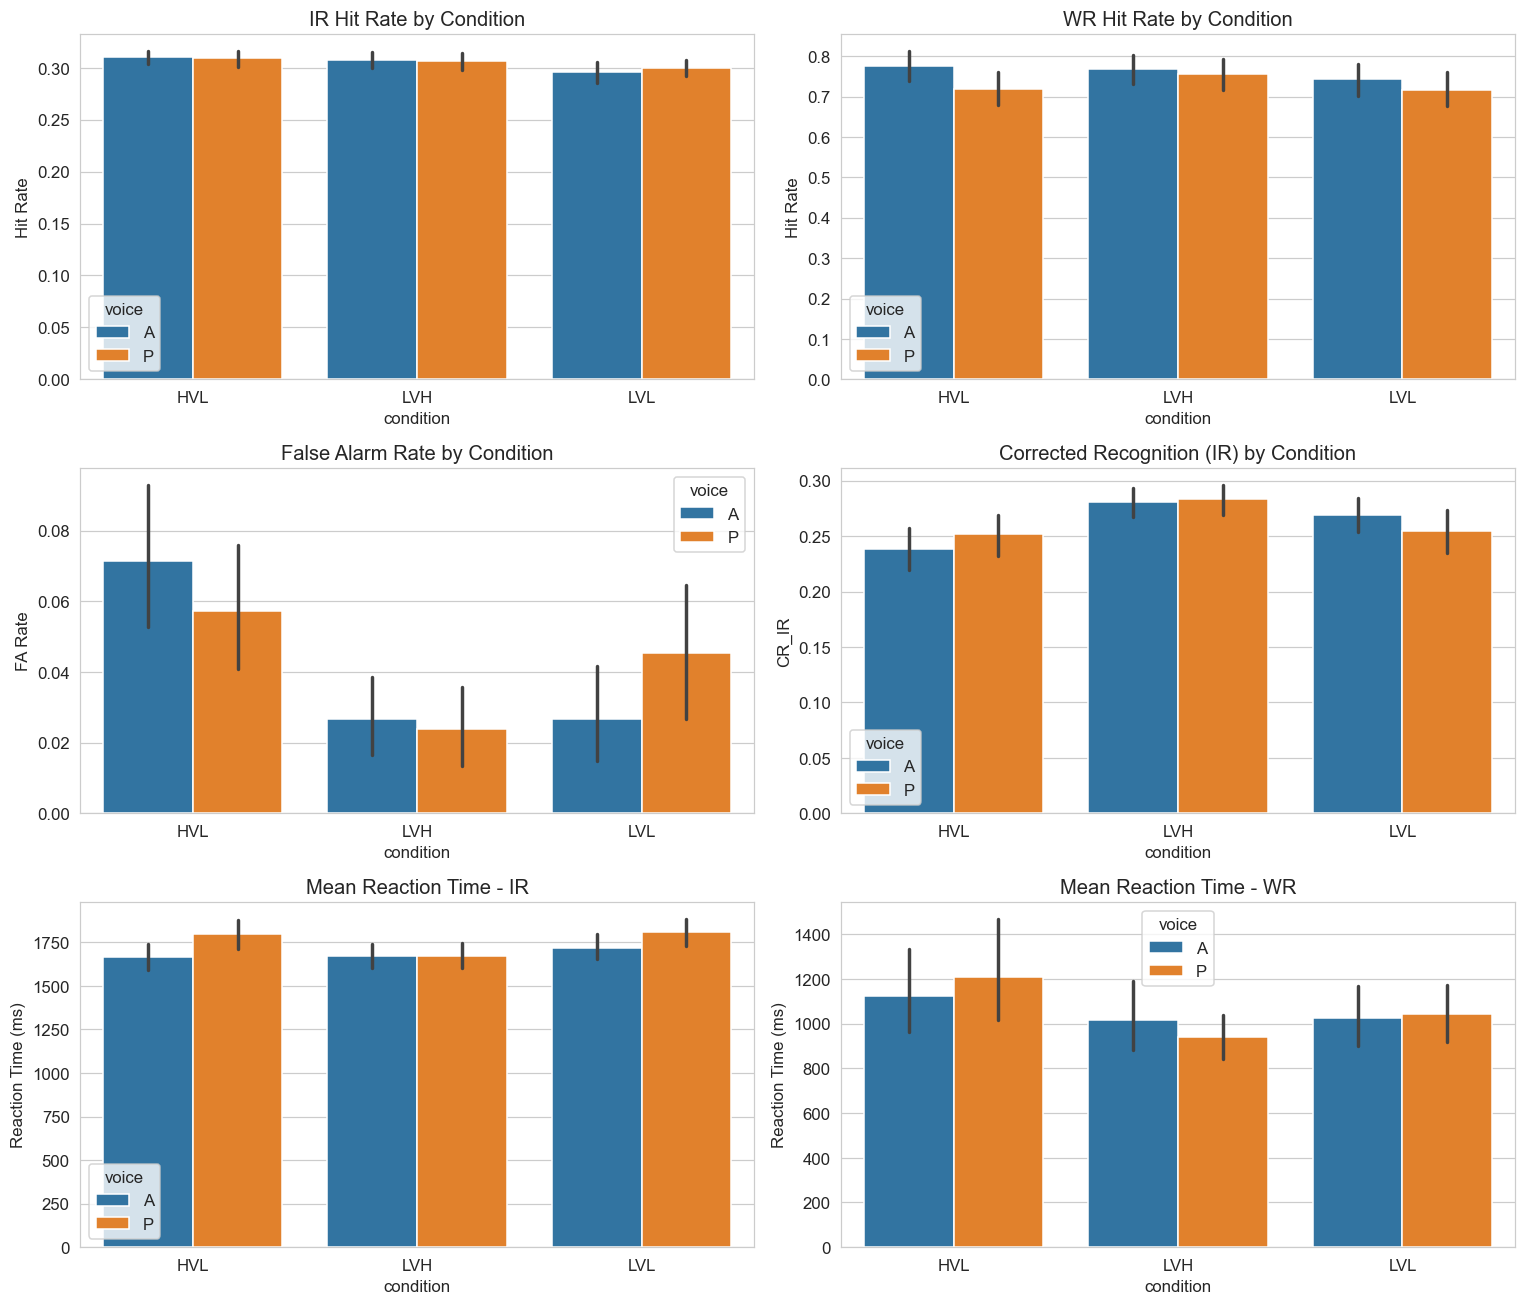

Max hit_rate_ir: 0.3333333333333333
n_targets distribution:
n_targets
4.0000       1
6.0000       7
8.0000       7
10.0000     31
12.0000     76
14.0000     99
16.0000    175
18.0000    276
Name: count, dtype: int64


In [72]:
def compute_CR_group(grp):
    # IR Hits
    target_repeats = grp[grp['_is_target'] & grp['_is_repeat'] & ~grp['_is_validation']]
    n_targets  = len(target_repeats)
    hits_ir    = (target_repeats['Accuracy IR'] == 1).sum()
    hit_rate_ir = hits_ir / n_targets if n_targets > 0 else np.nan

    # IR False Alarms (FIXED)
    ir_press_events = grp[grp['Event'] == 'IR pressed']
    fa_events = ir_press_events[~ir_press_events['_is_repeat'] & ~ir_press_events['_is_validation']]
    fa_count  = (fa_events['Accuracy IR'] == 0).sum()
    first_pres = grp[
        (grp['Event'] == 'Sentence shown') &
        ~grp['_is_repeat'] & ~grp['_is_validation']
    ]
    total_fp = len(first_pres)
    fa_rate  = fa_count / total_fp if total_fp > 0 else np.nan

    cr_ir = hit_rate_ir - fa_rate if not (np.isnan(hit_rate_ir) or np.isnan(fa_rate)) else np.nan

    # WR Hit rate
    wr_events  = grp[(grp['Event'] == 'WR pressed') & grp['_is_repeat'] & ~grp['_is_validation']]
    n_wr       = wr_events['Accuracy WR'].notna().sum()
    hits_wr    = (wr_events['Accuracy WR'] == 1).sum()
    hit_rate_wr = hits_wr / n_wr if n_wr > 0 else np.nan

    # RT
    rt_ir_vals = grp.loc[
        (grp['Event'] == 'IR pressed') & grp['_is_repeat'] & ~grp['_is_validation'],
        'Reaction_time_IR'
    ].dropna()
    rt_wr_vals = wr_events['Reaction_time_WR'].dropna()

    return pd.Series({
        'n_targets'    : n_targets,
        'hits_ir'      : hits_ir,
        'fa_count'     : fa_count,
        'total_fp'     : total_fp,
        'hit_rate_ir'  : hit_rate_ir,
        'fa_rate'      : fa_rate,
        'cr_ir'        : cr_ir,
        'n_wr'         : n_wr,
        'hits_wr'      : hits_wr,
        'hit_rate_wr'  : hit_rate_wr,
        'mean_rt_ir'   : rt_ir_vals.mean(),
        'median_rt_ir' : rt_ir_vals.median(),
        'mean_rt_wr'   : rt_wr_vals.mean(),
        'median_rt_wr' : rt_wr_vals.median(),
        'n_rt_ir'      : len(rt_ir_vals),
    })

exp_df = clean_df[clean_df['condition'].isin(TARGET_CONDITIONS)].copy()
cr_long = (
    exp_df.groupby(['participant_ID', 'condition', 'voice'])
    .apply(compute_CR_group)
    .reset_index()
)
cr_long['cond_voice'] = cr_long['condition'] + '_' + cr_long['voice']

print(f'cr_long shape: {cr_long.shape}  (expected: 672 rows)')
print()
print('FA rate distribution (FIXED — should no longer be all zeros):')
print(cr_long['fa_rate'].describe())
print(f'\nParticipants with FA rate = 0 in ALL conditions: '
      f'{(cr_long.groupby("participant_ID")["fa_rate"].max() == 0).sum()}')
print()
print('CR_IR descriptive stats by cond_voice (FIXED):')
print(cr_long.groupby('cond_voice')['cr_ir'].agg(['mean','median','std','min','max']).to_string())


# Comprehensive 3x2 grid with all metrics
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Row 1: Hit Rates
sns.barplot(data=cr_long, x='condition', y='hit_rate_ir', hue='voice', ax=axes[0, 0])
axes[0, 0].set_title('IR Hit Rate by Condition')
axes[0, 0].set_ylabel('Hit Rate')

sns.barplot(data=cr_long, x='condition', y='hit_rate_wr', hue='voice', ax=axes[0, 1])
axes[0, 1].set_title('WR Hit Rate by Condition')
axes[0, 1].set_ylabel('Hit Rate')

# Row 2: FA Rate & CR_IR
sns.barplot(data=cr_long, x='condition', y='fa_rate', hue='voice', ax=axes[1, 0])
axes[1, 0].set_title('False Alarm Rate by Condition')
axes[1, 0].set_ylabel('FA Rate')

sns.barplot(data=cr_long, x='condition', y='cr_ir', hue='voice', ax=axes[1, 1])
axes[1, 1].set_title('Corrected Recognition (IR) by Condition')
axes[1, 1].set_ylabel('CR_IR')

# Row 3: Reaction Times
sns.barplot(data=cr_long, x='condition', y='mean_rt_ir', hue='voice', ax=axes[2, 0])
axes[2, 0].set_title('Mean Reaction Time - IR')
axes[2, 0].set_ylabel('Reaction Time (ms)')

sns.barplot(data=cr_long, x='condition', y='mean_rt_wr', hue='voice', ax=axes[2, 1])
axes[2, 1].set_title('Mean Reaction Time - WR')
axes[2, 1].set_ylabel('Reaction Time (ms)')

plt.tight_layout()
plt.show()

print("Max hit_rate_ir:", cr_long['hit_rate_ir'].max())

print("n_targets distribution:")
print(cr_long['n_targets'].value_counts().sort_index())

## STEP 5 — Outlier Detection & RT Cleaning

We flag:
- **CR_IR IQR outliers** per condition (1.5×IQR rule)

In [73]:
# IQR outliers on CR_IR
outlier_records = []
print('IQR OUTLIER FLAGS FOR CR_IR:')
print(f'{"Condition":<12} {"N":<5} {"Mean":<7} {"Std":<7} {"Lo_fence":<10} {"Hi_fence":<10} {"n_out"}')
print('-'*65)
for cv in sorted(cr_long['cond_voice'].unique()):
    sub = cr_long[cr_long['cond_voice'] == cv][['participant_ID', 'cr_ir']].dropna()
    q1, q3 = sub['cr_ir'].quantile(0.25), sub['cr_ir'].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = sub[(sub['cr_ir'] < lo) | (sub['cr_ir'] > hi)]
    print(f'{cv:<12} {len(sub):<5} {sub["cr_ir"].mean():<7.3f} {sub["cr_ir"].std():<7.3f} {lo:<10.3f} {hi:<10.3f} {len(out)}')
    for _, row in out.iterrows():
        outlier_records.append({'participant_ID': row['participant_ID'], 'condition': cv.split('_')[0],
                                'voice': cv.split('_')[1], 'block': np.nan,
                                'variable': 'CR_IR', 'value': row['cr_ir'], 'flag': 'IQR_outlier'})

impossible = cr_long[(cr_long['cr_ir'] < -1) | (cr_long['cr_ir'] > 1)]
print(f'\nCR_IR outside [-1,+1] (impossible): {len(impossible)}')

IQR OUTLIER FLAGS FOR CR_IR:
Condition    N     Mean    Std     Lo_fence   Hi_fence   n_out
-----------------------------------------------------------------
HVL_A        112   0.239   0.106   -0.083     0.583      1
HVL_P        112   0.252   0.097   -0.083     0.583      0
LVH_A        112   0.281   0.069   0.125      0.458      3
LVH_P        112   0.283   0.072   0.214      0.405      21
LVL_A        112   0.269   0.087   0.125      0.458      10
LVL_P        112   0.255   0.105   0.000      0.533      5

CR_IR outside [-1,+1] (impossible): 0


## STEP 6 — Clean RT & Save Final Outputs

Recompute RT means after removing impossible/extreme values. Save `cr_long_CLEAN.csv` (long format for ANOVA) and `summary_CR_wide_CLEAN.csv` (wide format for Kruskal-Wallis).

In [74]:
def compute_clean_RT(grp):
    rt = grp.loc[
        (grp['Event'] == 'IR pressed') & grp['_is_repeat'] & ~grp['_is_validation'],
        'Reaction_time_IR'
    ].dropna()
    
    rt_wr = grp.loc[
        (grp['Event'] == 'WR pressed') & grp['_is_repeat'] & ~grp['_is_validation'],
        'Reaction_time_WR'
    ].dropna()
    
    return pd.Series({
        'mean_rt_ir_clean'   : rt.mean(),
        'median_rt_ir_clean' : rt.median(),
        'mean_rt_wr_clean'   : rt_wr.mean(),
        'n_rt_ir_clean'      : len(rt),
        'n_rt_wr_clean'      : len(rt_wr),
    })

rt_clean_long = (
    exp_df.groupby(['participant_ID', 'condition', 'voice'])
    .apply(compute_clean_RT)
    .reset_index()
)
rt_clean_long['cond_voice'] = rt_clean_long['condition'] + '_' + rt_clean_long['voice']

print('RT stats (all valid values, no threshold filtering):')
print(rt_clean_long.groupby('cond_voice')[['mean_rt_ir_clean','mean_rt_wr_clean']].mean().to_string())

cr_long_final = cr_long.merge(
    rt_clean_long[['participant_ID','condition','voice',
                   'mean_rt_ir_clean','median_rt_ir_clean','mean_rt_wr_clean','n_rt_ir_clean']],
    on=['participant_ID','condition','voice'], how='left'
)

summary_wide = cr_long_final.pivot_table(
    index='participant_ID',
    columns='cond_voice',
    values=['cr_ir','hit_rate_ir','fa_rate','hit_rate_wr','mean_rt_ir_clean','median_rt_ir_clean','mean_rt_wr_clean']
)
summary_wide.columns = ['_'.join(col).strip() for col in summary_wide.columns]
summary_wide = summary_wide.reset_index()

cr_long_final.to_csv(os.path.join(OUTPUT_DIR, 'cr_long_CLEAN.csv'), index=False)
summary_wide.to_csv(os.path.join(OUTPUT_DIR, 'summary_CR_wide_CLEAN.csv'), index=False)

print(f'\ncr_long_final shape : {cr_long_final.shape}')
print(f'summary_wide shape  : {summary_wide.shape}')
print('\n Saved all output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<48} {sz/1024:.1f} KB')

RT stats (all valid values, no threshold filtering):
            mean_rt_ir_clean  mean_rt_wr_clean
cond_voice                                    
HVL_A              1663.7237         1123.5439
HVL_P              1795.4841         1206.8111
LVH_A              1670.8227         1015.6263
LVH_P              1670.1446          941.5101
LVL_A              1717.1044         1024.2315
LVL_P              1808.0671         1041.3784

cr_long_final shape : (672, 23)
summary_wide shape  : (112, 43)

 Saved all output files:
  block_validity_CLEAN.csv                         7.7 KB
  cr_long_CLEAN.csv                                104.1 KB
  exclusion_report.csv                             9.7 KB
  summary_CR_wide_CLEAN.csv                        49.6 KB


## STEP 7 — EDA: Univariate Analysis of All Key Variables

For each key variable, we plot:
1. Histogram with KDE
2. Descriptive statistics
3. Skewness and kurtosis

**Key variables**: `cr_ir`, `hit_rate_ir`, `fa_rate`, `hit_rate_wr`, `mean_rt_ir_clean`, `mean_rt_wr_clean`



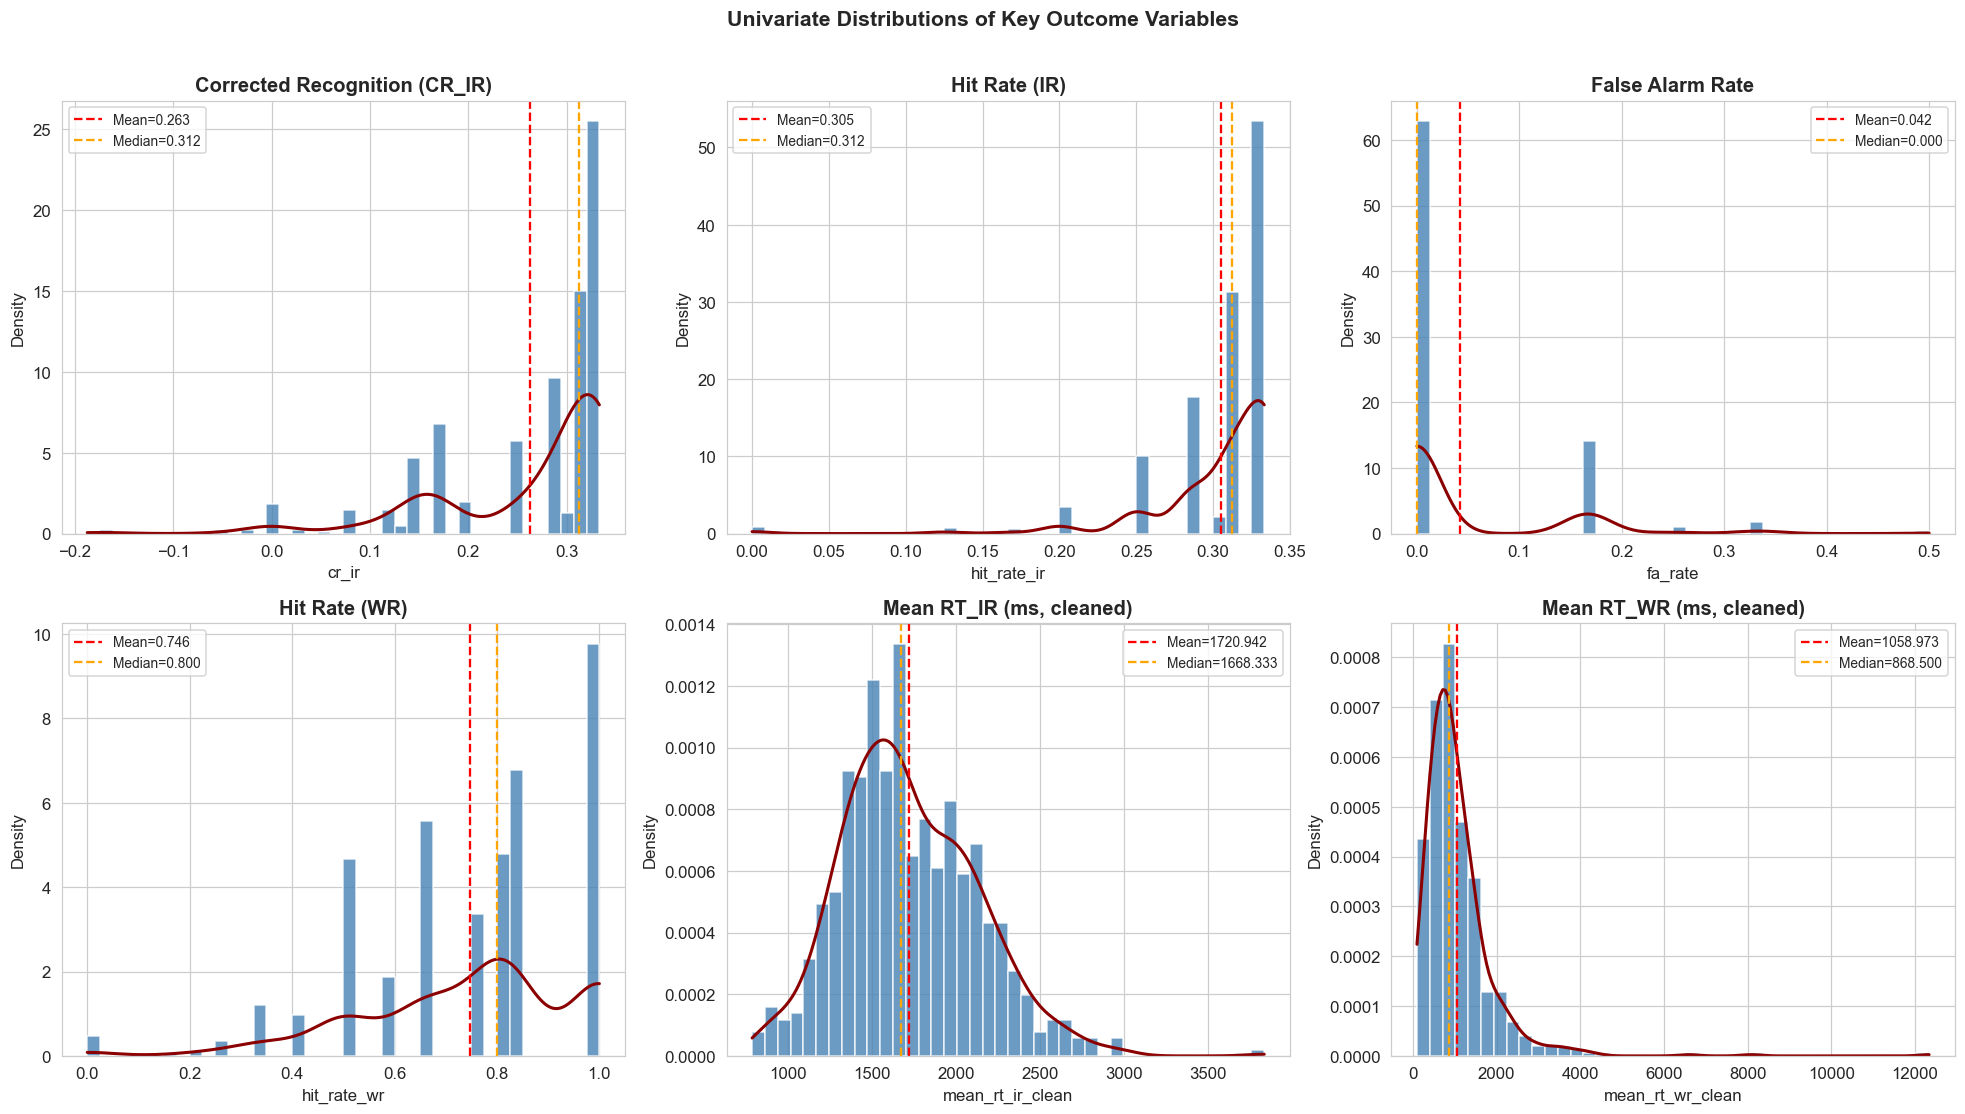


=== Descriptive Statistics ===
                    count      mean      std      min       25%       50%       75%        max  skewness  kurtosis
cr_ir            672.0000    0.2632   0.0915  -0.1875    0.2000    0.3125    0.3333     0.3333   -1.6329    2.6874
hit_rate_ir      672.0000    0.3051   0.0443   0.0000    0.2857    0.3125    0.3333     0.3333   -3.4127   17.1320
fa_rate          672.0000    0.0419   0.0864   0.0000    0.0000    0.0000    0.0000     0.5000    2.1335    4.6754
hit_rate_wr      667.0000    0.7465   0.2114   0.0000    0.6667    0.8000    0.8333     1.0000   -0.8338    0.7346
mean_rt_ir_clean 667.0000 1720.9418 404.0725 784.5000 1432.0000 1668.3333 1990.7333  3834.0000    0.5448    0.8511
mean_rt_wr_clean 667.0000 1058.9729 874.6268  92.0000  561.6500  868.5000 1315.1667 12341.5000    5.1080   50.0444


In [75]:
key_vars = ['cr_ir', 'hit_rate_ir', 'fa_rate', 'hit_rate_wr', 'mean_rt_ir_clean', 'mean_rt_wr_clean']
var_labels = {
    'cr_ir'             : 'Corrected Recognition (CR_IR)',
    'hit_rate_ir'       : 'Hit Rate (IR)',
    'fa_rate'           : 'False Alarm Rate',
    'hit_rate_wr'       : 'Hit Rate (WR)',
    'mean_rt_ir_clean'  : 'Mean RT_IR (ms, cleaned)',
    'mean_rt_wr_clean'  : 'Mean RT_WR (ms, cleaned)',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(key_vars):
    data = cr_long_final[var].dropna()
    ax = axes[idx]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), color='darkred', linewidth=2)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.3f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median={data.median():.3f}')
    ax.set_title(var_labels[var], fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Univariate Distributions of Key Outcome Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Descriptive stats table
print('\n=== Descriptive Statistics ===')
desc = cr_long_final[key_vars].describe().T
desc['skewness'] = cr_long_final[key_vars].skew()
desc['kurtosis'] = cr_long_final[key_vars].kurtosis()
print(desc.to_string())

## STEP 8 — EDA: Normality Tests

We run **Shapiro-Wilk** tests on each condition×voice group for `cr_ir`. This determines whether we should use parametric (ANOVA) or non-parametric (Kruskal-Wallis, Wilcoxon) tests.

**Expected**: Non-normality (p < 0.05) in several conditions due to the ceiling effect at 0.333. This is why the plan is to use Kruskal-Wallis.

**Also plots Q-Q plots** — deviations from the diagonal indicate non-normality.

In [76]:
from scipy.stats import shapiro, normaltest

print('=== Shapiro-Wilk Normality Tests for CR_IR per Condition × Voice ===')
print(f'{"Cond_Voice":<12} {"N":<5} {"W-stat":<10} {"p-value":<12} {"Normal?"}')
print('-'*50)

normality_results = []
cond_order = sorted(cr_long_final['cond_voice'].unique())
for cv in cond_order:
    data = cr_long_final[cr_long_final['cond_voice'] == cv]['cr_ir'].dropna()
    if len(data) >= 8:
        stat, p = shapiro(data)
        normal = ' Yes' if p > 0.05 else ' No'
        print(f'{cv:<12} {len(data):<5} {stat:<10.4f} {p:<12.22f} {normal}')
        normality_results.append({'cond_voice': cv, 'W': stat, 'p': p, 'normal': p > 0.05})

normality_df = pd.DataFrame(normality_results)
print(f'\n{normality_df["normal"].sum()} / {len(normality_df)} conditions are normally distributed')

=== Shapiro-Wilk Normality Tests for CR_IR per Condition × Voice ===
Cond_Voice   N     W-stat     p-value      Normal?
--------------------------------------------------
HVL_A        112   0.8320     0.0000000005926356480625  No
HVL_P        112   0.8039     0.0000000000651888216808  No
LVH_A        112   0.7377     0.0000000000007397518700  No
LVH_P        112   0.7176     0.0000000000002230384396  No
LVL_A        112   0.7193     0.0000000000002449331640  No
LVL_P        112   0.7513     0.0000000000017283003963  No

0 / 6 conditions are normally distributed


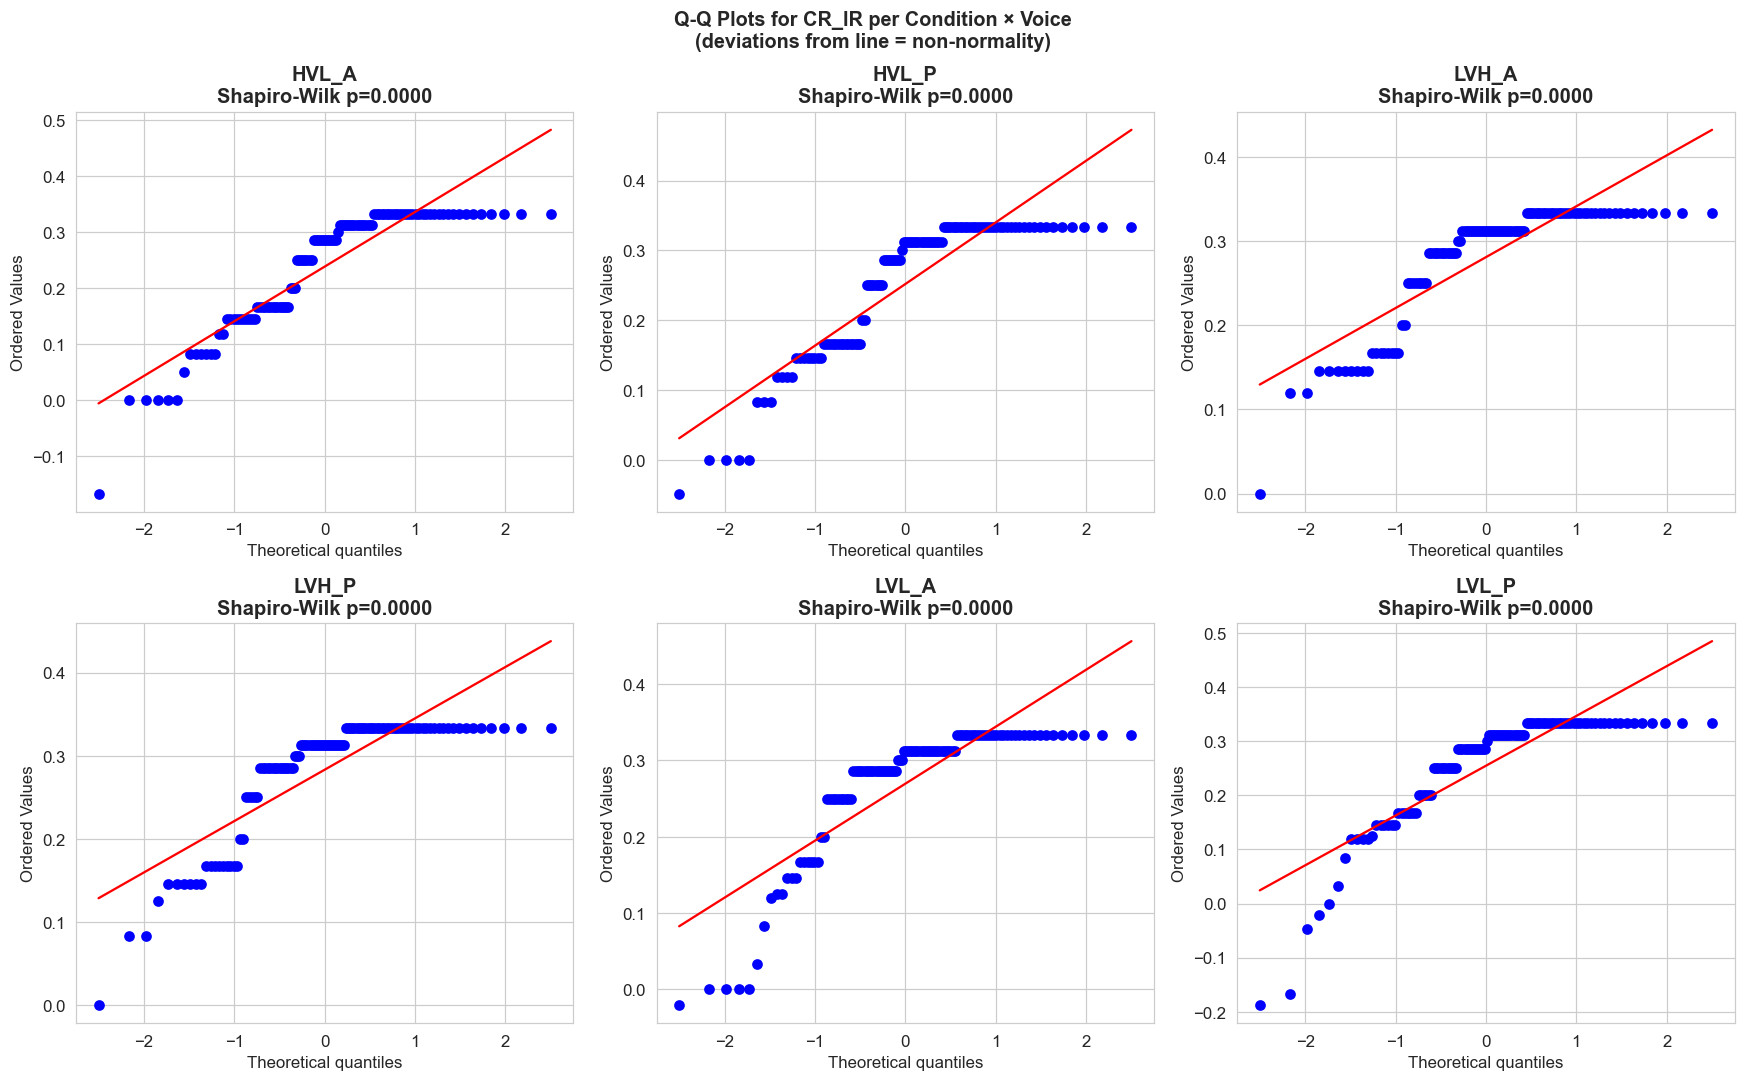

In [77]:
# Q-Q plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, cv in enumerate(cond_order):
    data = cr_long_final[cr_long_final['cond_voice'] == cv]['cr_ir'].dropna()
    stats.probplot(data, plot=axes[idx])
    sw_stat, sw_p = shapiro(data)
    axes[idx].set_title(f'{cv}\nShapiro-Wilk p={sw_p:.4f}', fontweight='bold')

plt.suptitle('Q-Q Plots for CR_IR per Condition × Voice\n(deviations from line = non-normality)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9 — EDA: Condition-level Analysis

### 9a — Boxplots by Condition × Voice



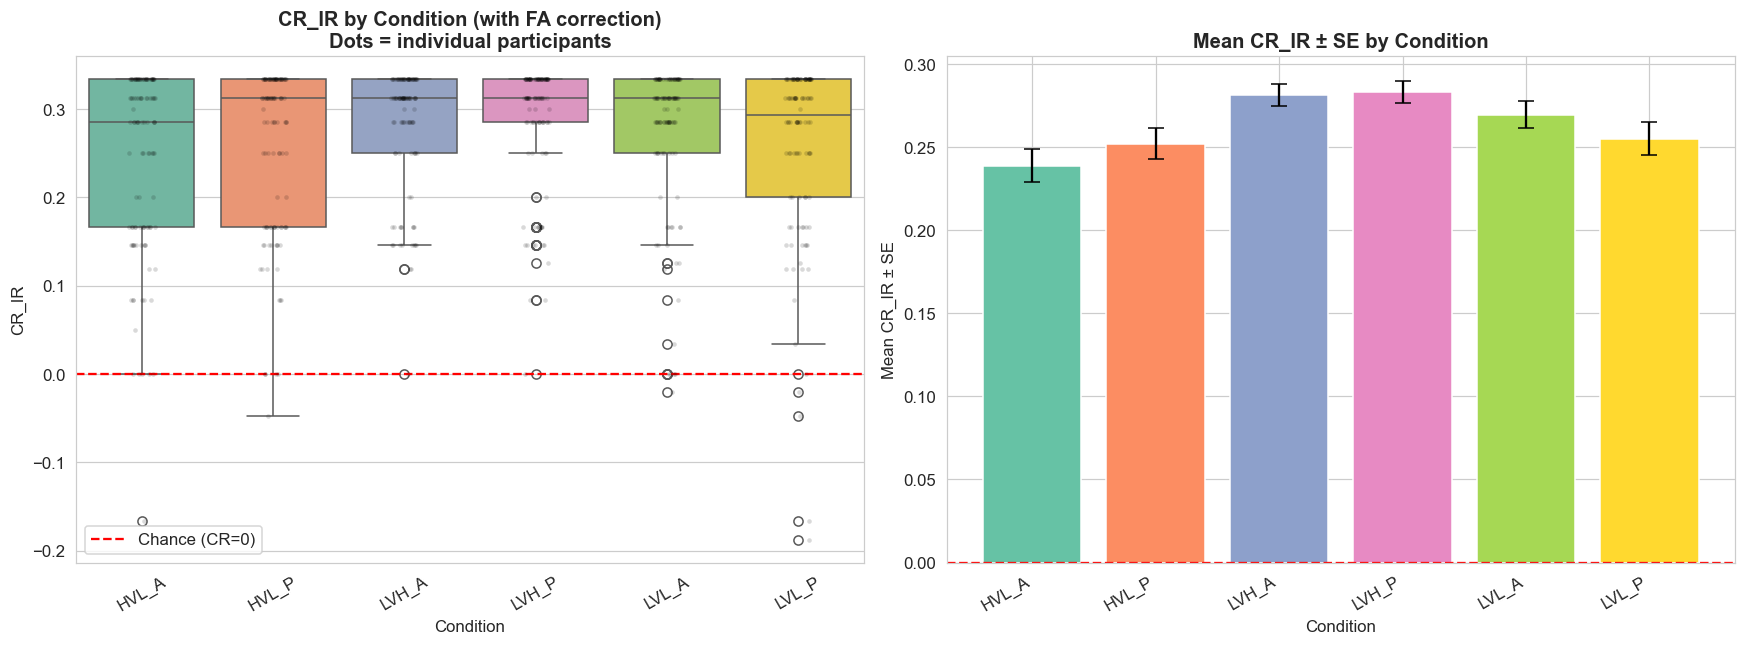

Mean CR_IR by condition:
             mean  median    std  count
cond_voice                             
HVL_A      0.2388  0.2857 0.1055    112
HVL_P      0.2520  0.3125 0.0967    112
LVH_A      0.2810  0.3125 0.0695    112
LVH_P      0.2831  0.3125 0.0720    112
LVL_A      0.2695  0.3125 0.0869    112
LVL_P      0.2549  0.2929 0.1049    112


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=cr_long_final, x='cond_voice', y='cr_ir', order=cond_order,
            ax=axes[0], palette='Set2', showfliers=True)
sns.stripplot(data=cr_long_final, x='cond_voice', y='cr_ir', order=cond_order,
              ax=axes[0], color='black', alpha=0.15, size=3, jitter=True)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Chance (CR=0)')
axes[0].set_title('CR_IR by Condition (with FA correction)\nDots = individual participants', fontweight='bold')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('CR_IR')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Mean ± SE bar
means = cr_long_final.groupby('cond_voice')['cr_ir'].mean().reindex(cond_order)
ses   = cr_long_final.groupby('cond_voice')['cr_ir'].sem().reindex(cond_order)
colors = sns.color_palette('Set2', len(cond_order))
axes[1].bar(cond_order, means.values, yerr=ses.values, capsize=5, color=colors, edgecolor='white')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Mean CR_IR ± SE')
axes[1].set_title('Mean CR_IR ± SE by Condition', fontweight='bold')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Mean CR_IR by condition:')
print(cr_long_final.groupby('cond_voice')['cr_ir'].agg(['mean','median','std','count']).to_string())

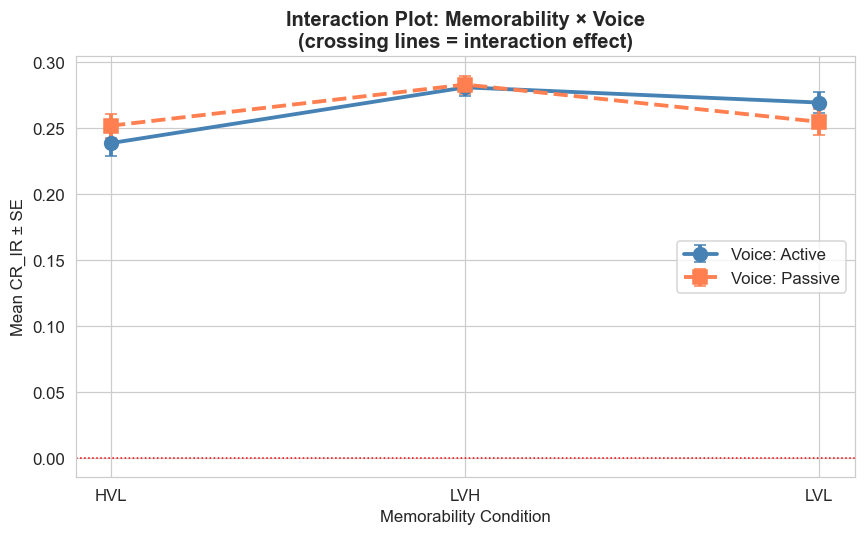

Interaction table:
condition voice   mean    sem
      HVL     A 0.2388 0.0100
      HVL     P 0.2520 0.0091
      LVH     A 0.2810 0.0066
      LVH     P 0.2831 0.0068
      LVL     A 0.2695 0.0082
      LVL     P 0.2549 0.0099


In [79]:
# 9b — Interaction plot: Memorability × Voice
interaction = cr_long_final.groupby(['condition', 'voice'])['cr_ir'].agg(
    mean='mean', sem=lambda x: x.sem()
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for voice, ls, mk, col in [('A', '-', 'o', 'steelblue'), ('P', '--', 's', 'coral')]:
    sub = interaction[interaction['voice'] == voice]
    ax.errorbar(sub['condition'], sub['mean'], yerr=sub['sem'],
                linestyle=ls, marker=mk, capsize=4, linewidth=2.5,
                markersize=9, color=col, label=f'Voice: {"Active" if voice=="A" else "Passive"}')
ax.axhline(0, color='red', linestyle=':', linewidth=1)
ax.set_xlabel('Memorability Condition')
ax.set_ylabel('Mean CR_IR ± SE')
ax.set_title('Interaction Plot: Memorability × Voice\n(crossing lines = interaction effect)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Interaction table:')
print(interaction.to_string(index=False))


There is no strong evidence of an interaction between memorability and voice, as the pattern of memorability effects is consistent across both active and passive sentences.

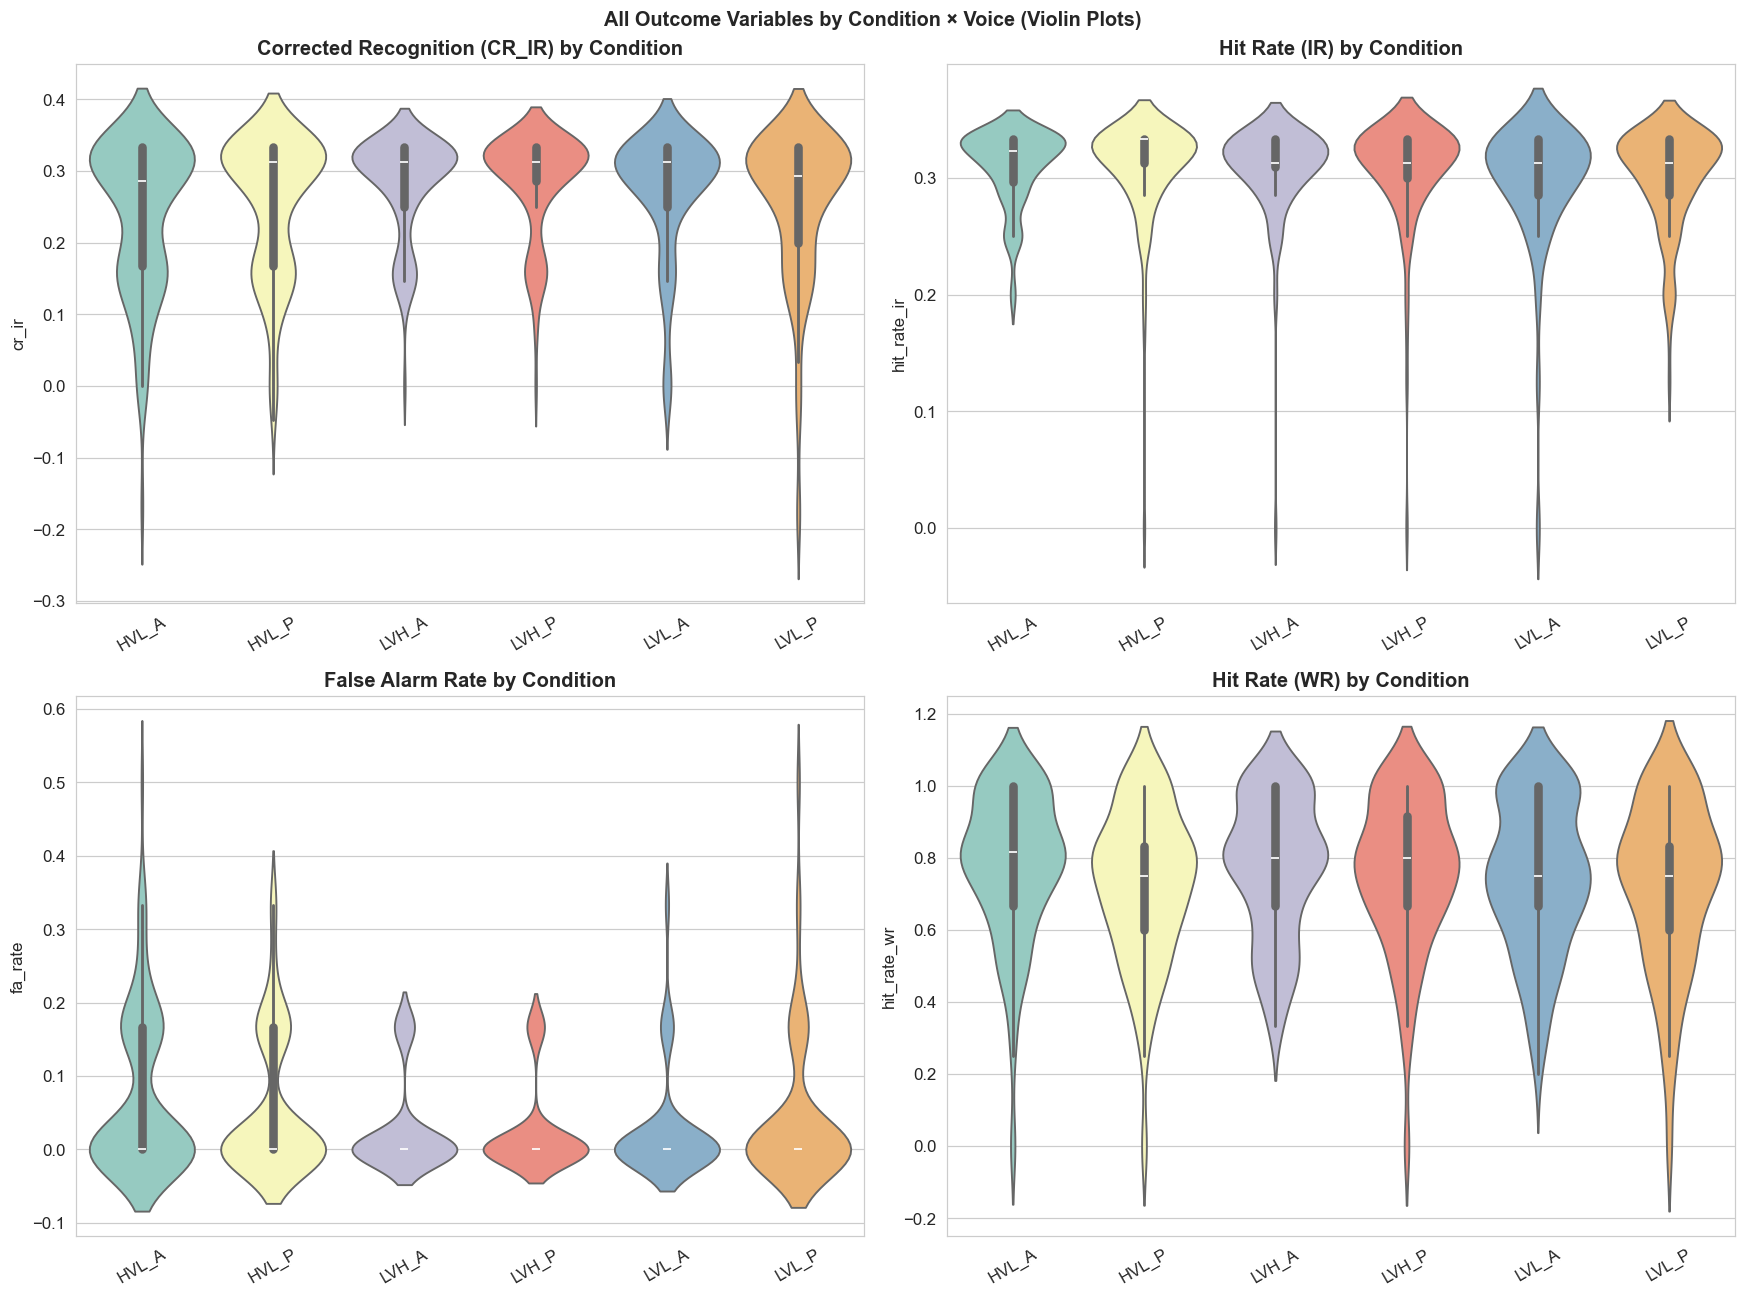

In [80]:
# 9c — All outcome variables by condition
outcome_vars = ['cr_ir', 'hit_rate_ir', 'fa_rate', 'hit_rate_wr']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, var in enumerate(outcome_vars):
    sns.violinplot(data=cr_long_final, x='cond_voice', y=var, order=cond_order,
                   ax=axes[idx], palette='Set3', inner='box')
    axes[idx].set_title(f'{var_labels.get(var, var)} by Condition', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('All Outcome Variables by Condition × Voice (Violin Plots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 10 — EDA: Participant-Level Quality Checks

We check for:
1. **Participants who never respond (all FA rate = 0)**: they may have pressed spacebar only on repeats, or not at all
2. **Participants with suspiciously high or low CR_IR across all conditions**
3. **Distribution of how many valid conditions each participant has**
4. **Per-participant mean CR_IR distribution** (identify potential random responders or non-engagers)

**Expected**: Most participants should have mean CR_IR between 0.1 and 0.35. Participants near 0 may be random responders.

In [81]:
# Per-participant summary
p_summary = cr_long_final.groupby('participant_ID').agg(
    mean_cr_ir      = ('cr_ir', 'mean'),
    std_cr_ir       = ('cr_ir', 'std'),
    mean_hit_rate   = ('hit_rate_ir', 'mean'),
    mean_fa_rate    = ('fa_rate', 'mean'),
    mean_hit_wr     = ('hit_rate_wr', 'mean'),
    mean_rt_ir      = ('mean_rt_ir_clean', 'mean'),
    n_conditions    = ('cond_voice', 'count'),
).reset_index()

print('Per-participant summary stats:')
print(p_summary.describe().to_string())
print()

# Flag suspicious participants
low_cr   = p_summary[p_summary['mean_cr_ir'] < 0.05]
high_fa  = p_summary[p_summary['mean_fa_rate'] > 0.2]
all_fa_0 = p_summary[p_summary['mean_fa_rate'] == 0.0]

print(f'Participants with mean CR_IR < 0.05 (near chance): {len(low_cr)}')
if len(low_cr) > 0: print(low_cr[['participant_ID','mean_cr_ir','mean_fa_rate']].to_string())

print(f'\nParticipants with mean FA rate > 0.2 (high false alarms): {len(high_fa)}')
if len(high_fa) > 0: print(high_fa[['participant_ID','mean_cr_ir','mean_fa_rate']].to_string())

print(f'\nParticipants with FA rate = 0 in ALL conditions: {len(all_fa_0)}')

Per-participant summary stats:
       participant_ID  mean_cr_ir  std_cr_ir  mean_hit_rate  mean_fa_rate  mean_hit_wr  mean_rt_ir  n_conditions
count        112.0000    112.0000   112.0000       112.0000      112.0000     112.0000    112.0000      112.0000
mean         315.8125      0.2632     0.0749         0.3051        0.0419       0.7445   1723.7455        6.0000
std           48.3697      0.0473     0.0422         0.0350        0.0411       0.1177    299.5981        0.0000
min          232.0000      0.0750     0.0085         0.0750        0.0000       0.3000    893.5833        6.0000
25%          275.2500      0.2388     0.0519         0.2965        0.0000       0.6833   1512.7743        6.0000
50%          312.5000      0.2743     0.0741         0.3150        0.0278       0.7500   1689.2847        6.0000
75%          362.2500      0.2979     0.0914         0.3264        0.0556       0.8278   1896.0375        6.0000
max          398.0000      0.3299     0.2041         0.3333      

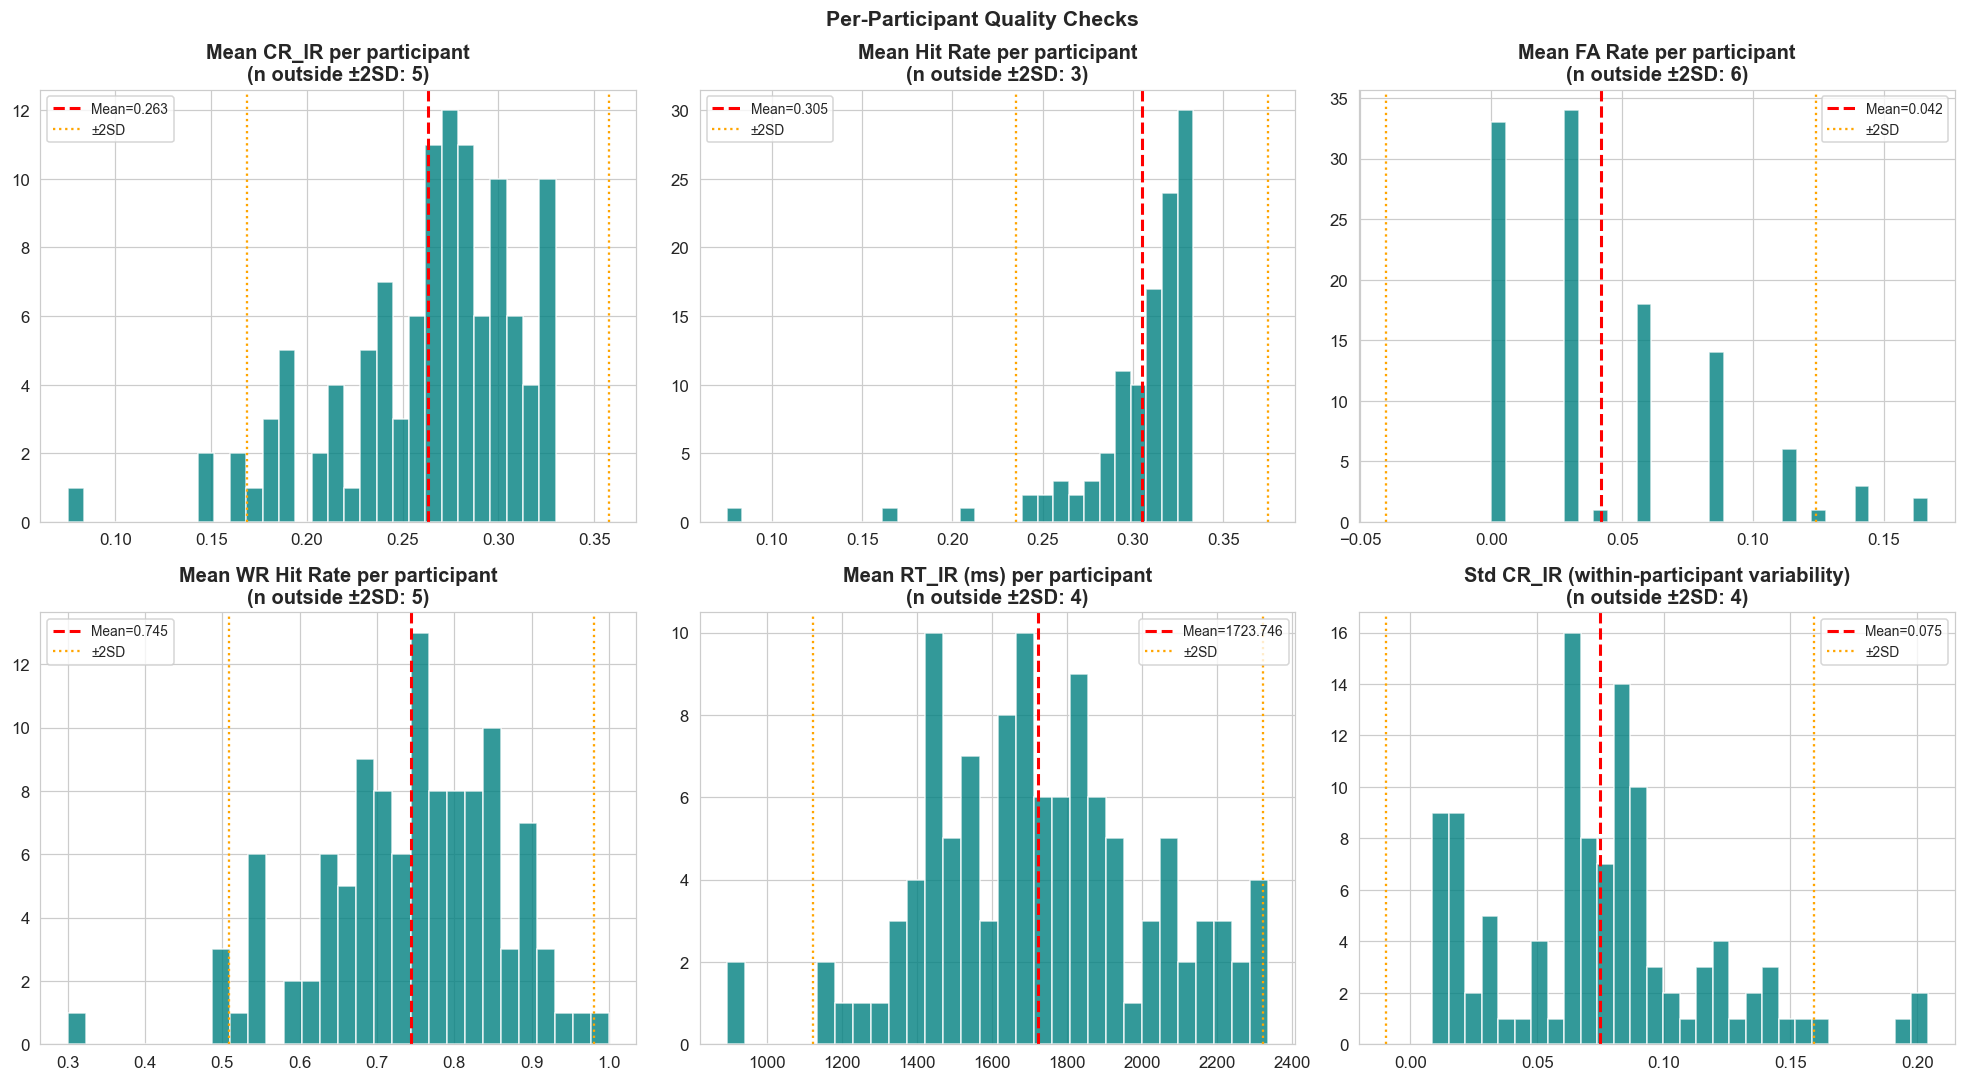

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

p_vars = ['mean_cr_ir', 'mean_hit_rate', 'mean_fa_rate', 'mean_hit_wr', 'mean_rt_ir', 'std_cr_ir']
p_titles = ['Mean CR_IR per participant', 'Mean Hit Rate per participant',
            'Mean FA Rate per participant', 'Mean WR Hit Rate per participant',
            'Mean RT_IR (ms) per participant', 'Std CR_IR (within-participant variability)']

for idx, (var, title) in enumerate(zip(p_vars, p_titles)):
    data = p_summary[var].dropna()
    axes[idx].hist(data, bins=30, color='teal', edgecolor='white', alpha=0.8)
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={data.mean():.3f}')
    # ±2 SD lines
    lo, hi = data.mean() - 2*data.std(), data.mean() + 2*data.std()
    axes[idx].axvline(lo, color='orange', linestyle=':', linewidth=1.5, label=f'±2SD')
    axes[idx].axvline(hi, color='orange', linestyle=':', linewidth=1.5)
    n_outliers = ((data < lo) | (data > hi)).sum()
    axes[idx].set_title(f'{title}\n(n outside ±2SD: {n_outliers})', fontweight='bold')
    axes[idx].legend(fontsize=9)

plt.suptitle('Per-Participant Quality Checks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

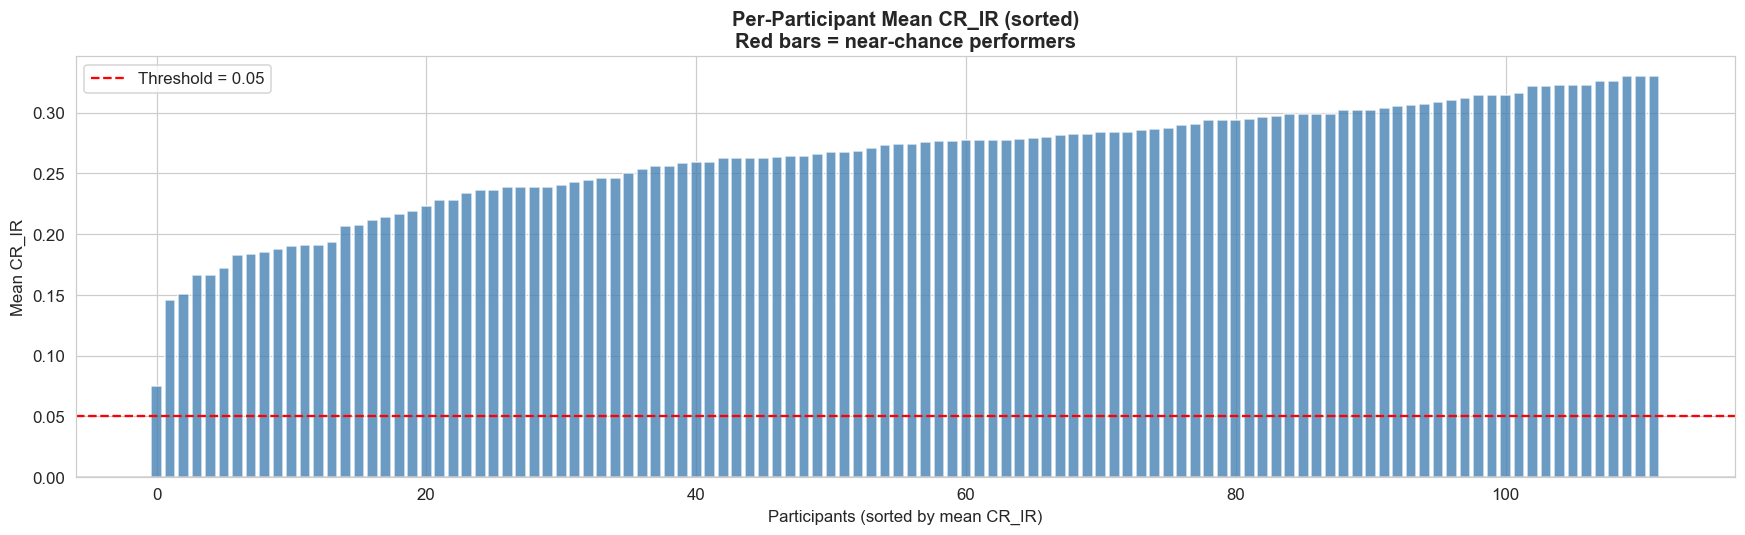

Near-chance participants (mean CR_IR < 0.05): 0
Empty DataFrame
Columns: [participant_ID, mean_cr_ir, mean_fa_rate, mean_hit_rate]
Index: []


In [83]:
# Sorted participant plot — to spot systematic outliers
fig, ax = plt.subplots(figsize=(16, 5))
p_sorted = p_summary.sort_values('mean_cr_ir')
colors_p = ['red' if v < 0.05 else 'steelblue' for v in p_sorted['mean_cr_ir']]
ax.bar(range(len(p_sorted)), p_sorted['mean_cr_ir'], color=colors_p, alpha=0.8)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.05')
ax.set_xlabel('Participants (sorted by mean CR_IR)')
ax.set_ylabel('Mean CR_IR')
ax.set_title('Per-Participant Mean CR_IR (sorted)\nRed bars = near-chance performers', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Identify them
near_chance = p_sorted[p_sorted['mean_cr_ir'] < 0.05]
print(f'Near-chance participants (mean CR_IR < 0.05): {len(near_chance)}')
print(near_chance[['participant_ID','mean_cr_ir','mean_fa_rate','mean_hit_rate']].to_string())

## STEP 11 — EDA: Block Effects & Learning / Fatigue

We check if hit rate systematically increases (learning) or decreases (fatigue) across the 3 blocks.

**Expected**: Slight decline across blocks (fatigue) or slight increase (learning effect). Large changes would be suspicious.

**Watch for**: If block 1 is consistently much higher than blocks 2 and 3, it could indicate a primacy effect (better memory for earlier items).

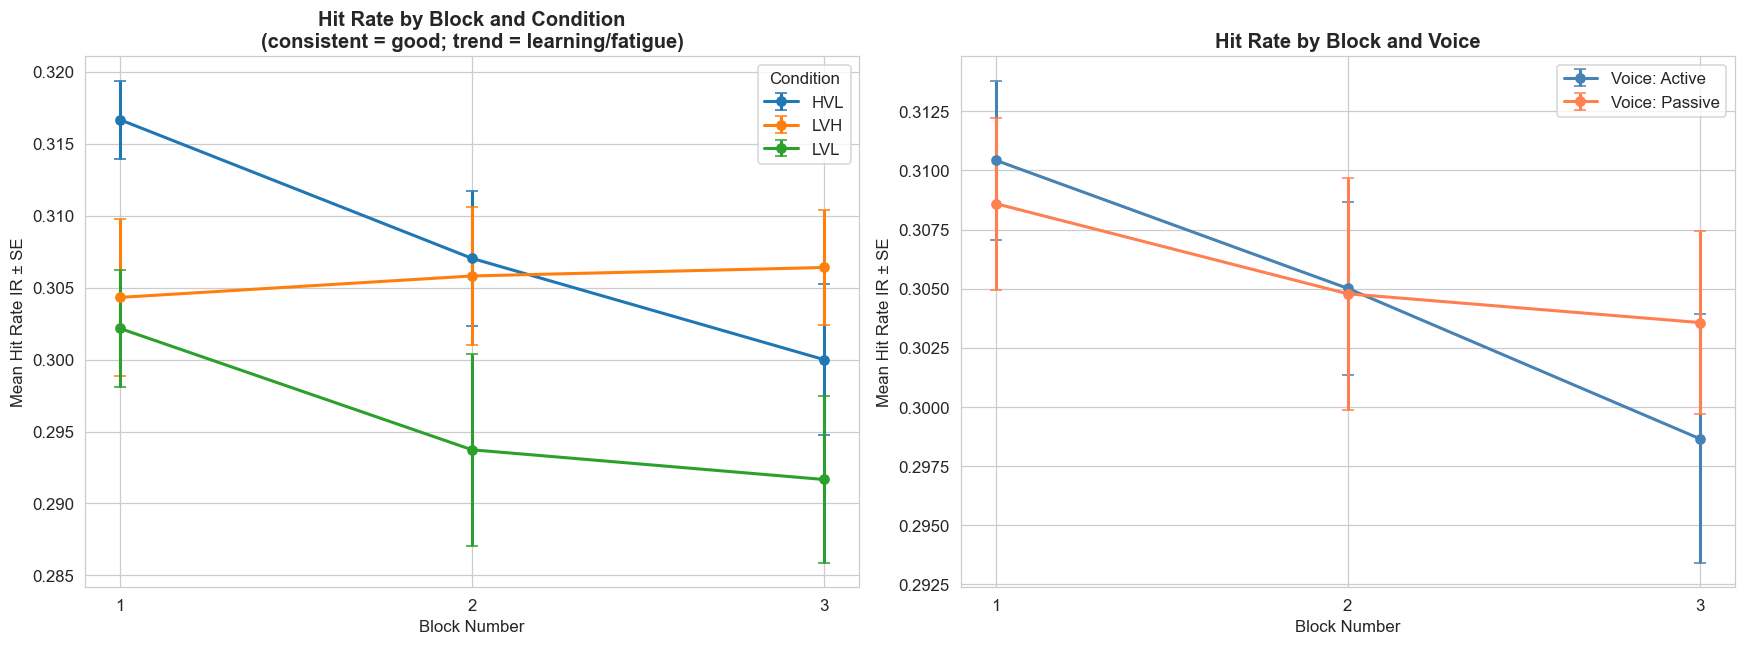

Mean hit rate by block:
        mean    std  count
block                     
1     0.3077 0.0444    324
2     0.3022 0.0572    327
3     0.2994 0.0539    336


In [84]:
# Hit rate by block and condition
block_cr = (
    exp_df.groupby(['participant_ID', 'block', 'condition'])
    .apply(lambda g: pd.Series({
        'hit_rate': (g.loc[(g['Event']=='IR pressed') & g['_is_repeat'] &
                           ~g['_is_validation'], 'Accuracy IR'] == 1).sum() /
                     max((g['_is_target'] & g['_is_repeat'] & ~g['_is_validation']).sum(), 1)
    }))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Block × Condition
for cond in TARGET_CONDITIONS:
    sub = block_cr[block_cr['condition'] == cond]
    sub_mean = sub.groupby('block')['hit_rate'].mean()
    sub_se   = sub.groupby('block')['hit_rate'].sem()
    axes[0].errorbar(sub_mean.index, sub_mean.values, yerr=sub_se.values,
                     marker='o', capsize=4, linewidth=2, label=cond)
axes[0].set_xlabel('Block Number')
axes[0].set_ylabel('Mean Hit Rate IR ± SE')
axes[0].set_title('Hit Rate by Block and Condition\n(consistent = good; trend = learning/fatigue)', fontweight='bold')
axes[0].legend(title='Condition')
axes[0].set_xticks([1, 2, 3])

# Block × Voice
block_voice = (
    exp_df[exp_df['condition'].isin(TARGET_CONDITIONS)]
    .groupby(['participant_ID', 'block', 'voice'])
    .apply(lambda g: pd.Series({
        'hit_rate': (g.loc[(g['Event']=='IR pressed') & g['_is_repeat'] &
                           ~g['_is_validation'], 'Accuracy IR'] == 1).sum() /
                     max((g['_is_target'] & g['_is_repeat'] & ~g['_is_validation']).sum(), 1)
    }))
    .reset_index()
)
for voice, col in [('A', 'steelblue'), ('P', 'coral')]:
    sub = block_voice[block_voice['voice'] == voice]
    sub_mean = sub.groupby('block')['hit_rate'].mean()
    sub_se   = sub.groupby('block')['hit_rate'].sem()
    axes[1].errorbar(sub_mean.index, sub_mean.values, yerr=sub_se.values,
                     marker='o', capsize=4, linewidth=2, color=col,
                     label=f'Voice: {"Active" if voice=="A" else "Passive"}')
axes[1].set_xlabel('Block Number')
axes[1].set_ylabel('Mean Hit Rate IR ± SE')
axes[1].set_title('Hit Rate by Block and Voice', fontweight='bold')
axes[1].legend()
axes[1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

print('Mean hit rate by block:')
print(block_cr.groupby('block')['hit_rate'].agg(['mean','std','count']).to_string())

## STEP 12 — EDA: Bivariate & Correlation Analysis

### 12a — Correlation Heatmap

We compute Spearman correlations (rank-based, suitable for non-normal data) between all key outcome variables across participants.

**Expected relationships**:
- Strong positive correlation between `cr_ir` values across conditions (participants who do well in one condition do well in all)
- `hit_rate_ir` and `cr_ir` should be highly correlated
- `fa_rate` and `cr_ir` should be negatively correlated
- RT_IR and hit_rate may be negatively correlated (faster responders = better memory)

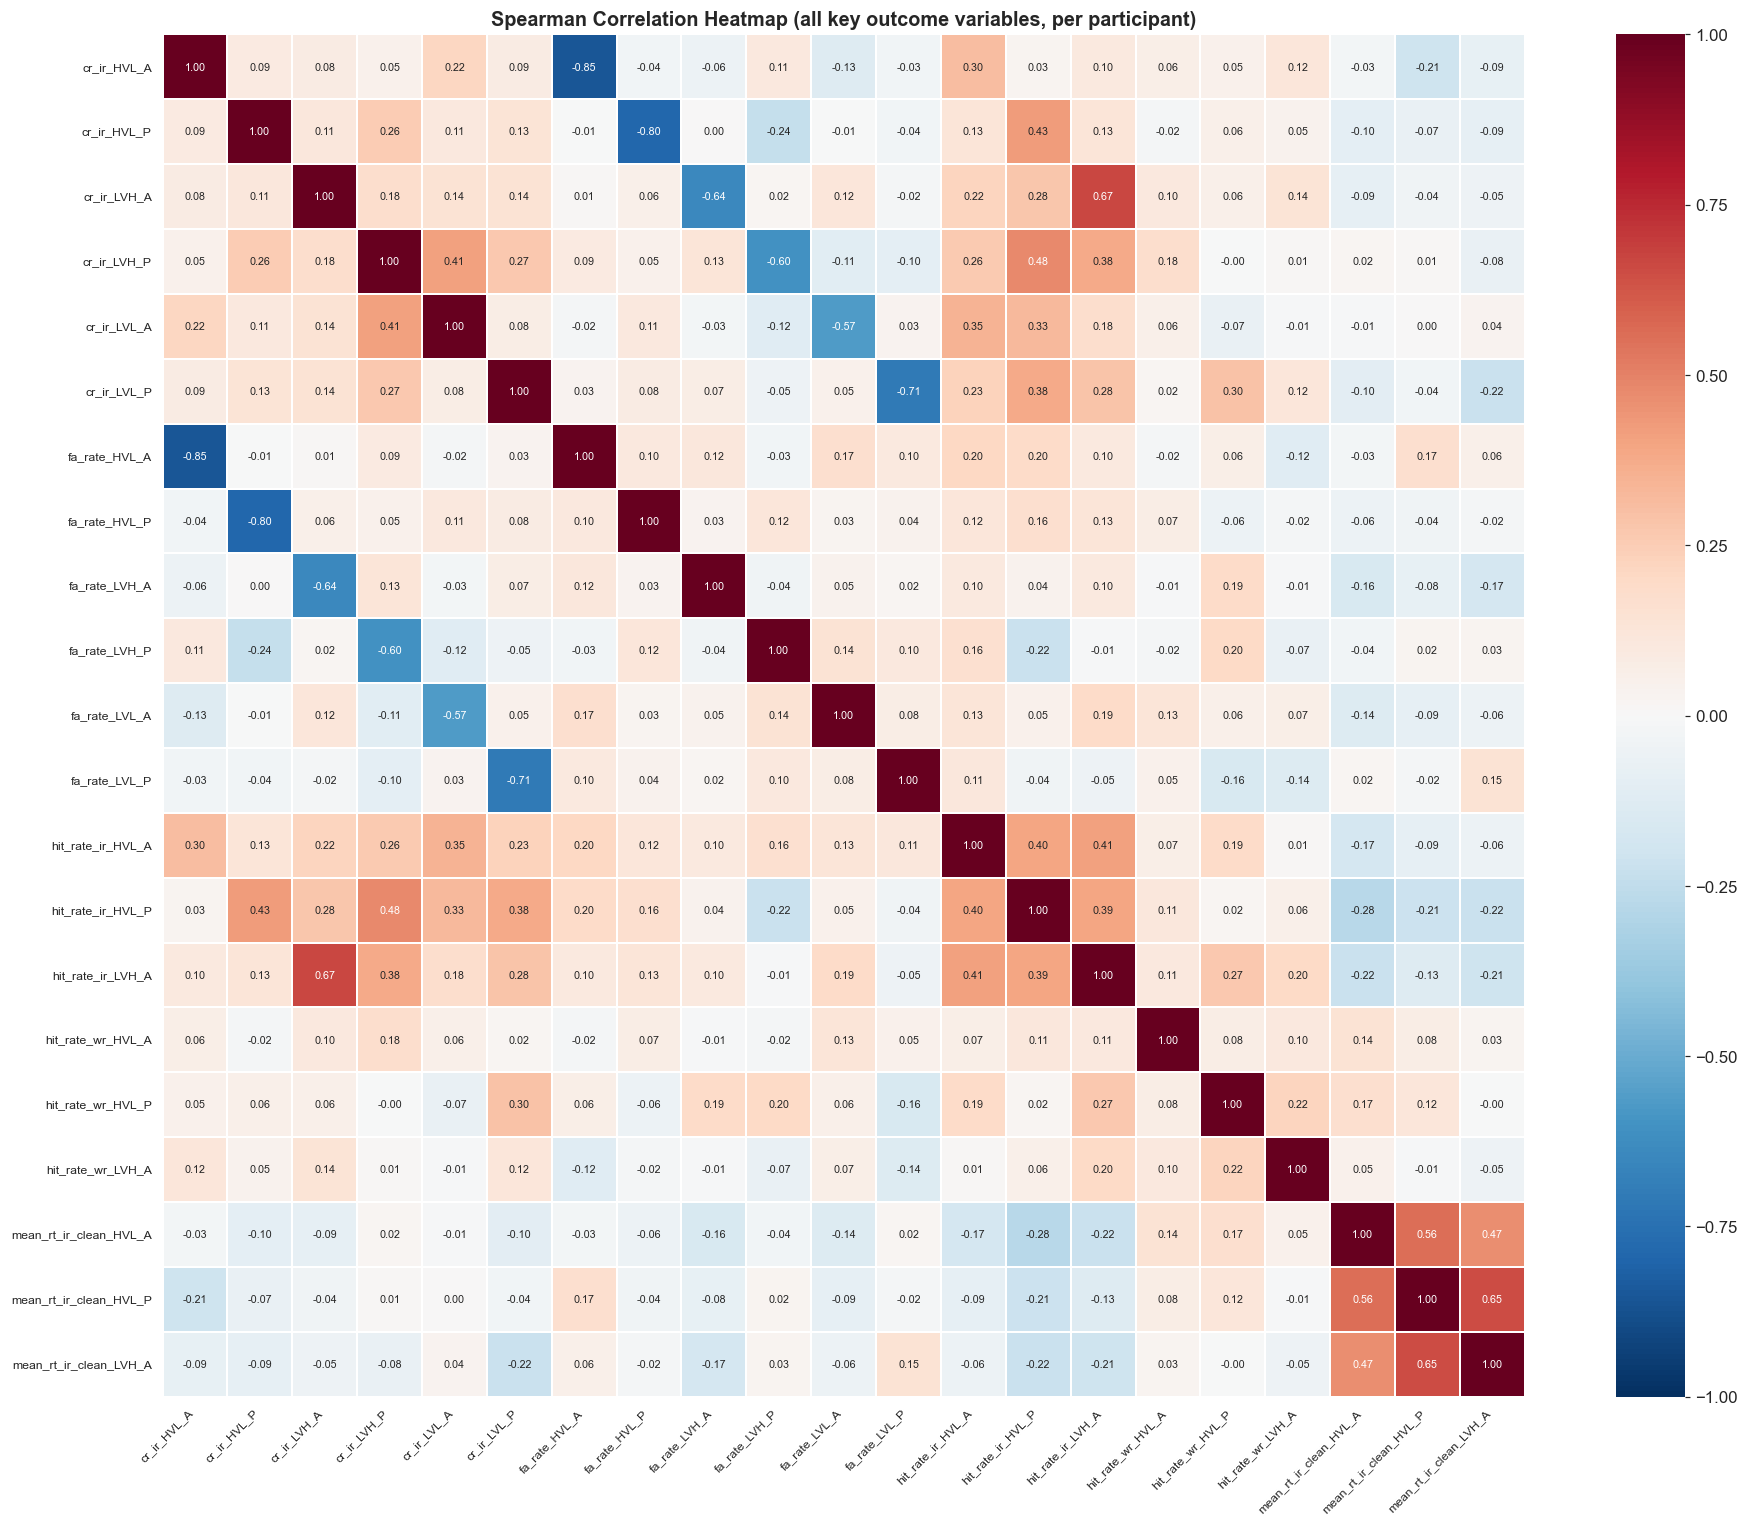

In [85]:
# Wide format correlation — use summary_wide
cr_cols = [c for c in summary_wide.columns if c.startswith('cr_ir_')]
hr_cols = [c for c in summary_wide.columns if c.startswith('hit_rate_ir_')]
fa_cols = [c for c in summary_wide.columns if c.startswith('fa_rate_')]
wr_cols = [c for c in summary_wide.columns if c.startswith('hit_rate_wr_')]
rt_cols = [c for c in summary_wide.columns if c.startswith('mean_rt_ir_clean_')]

corr_cols = cr_cols + fa_cols + hr_cols[:3] + wr_cols[:3] + rt_cols[:3]
corr_matrix = summary_wide[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.3,
            annot_kws={'size': 7})
ax.set_title('Spearman Correlation Heatmap (all key outcome variables, per participant)',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

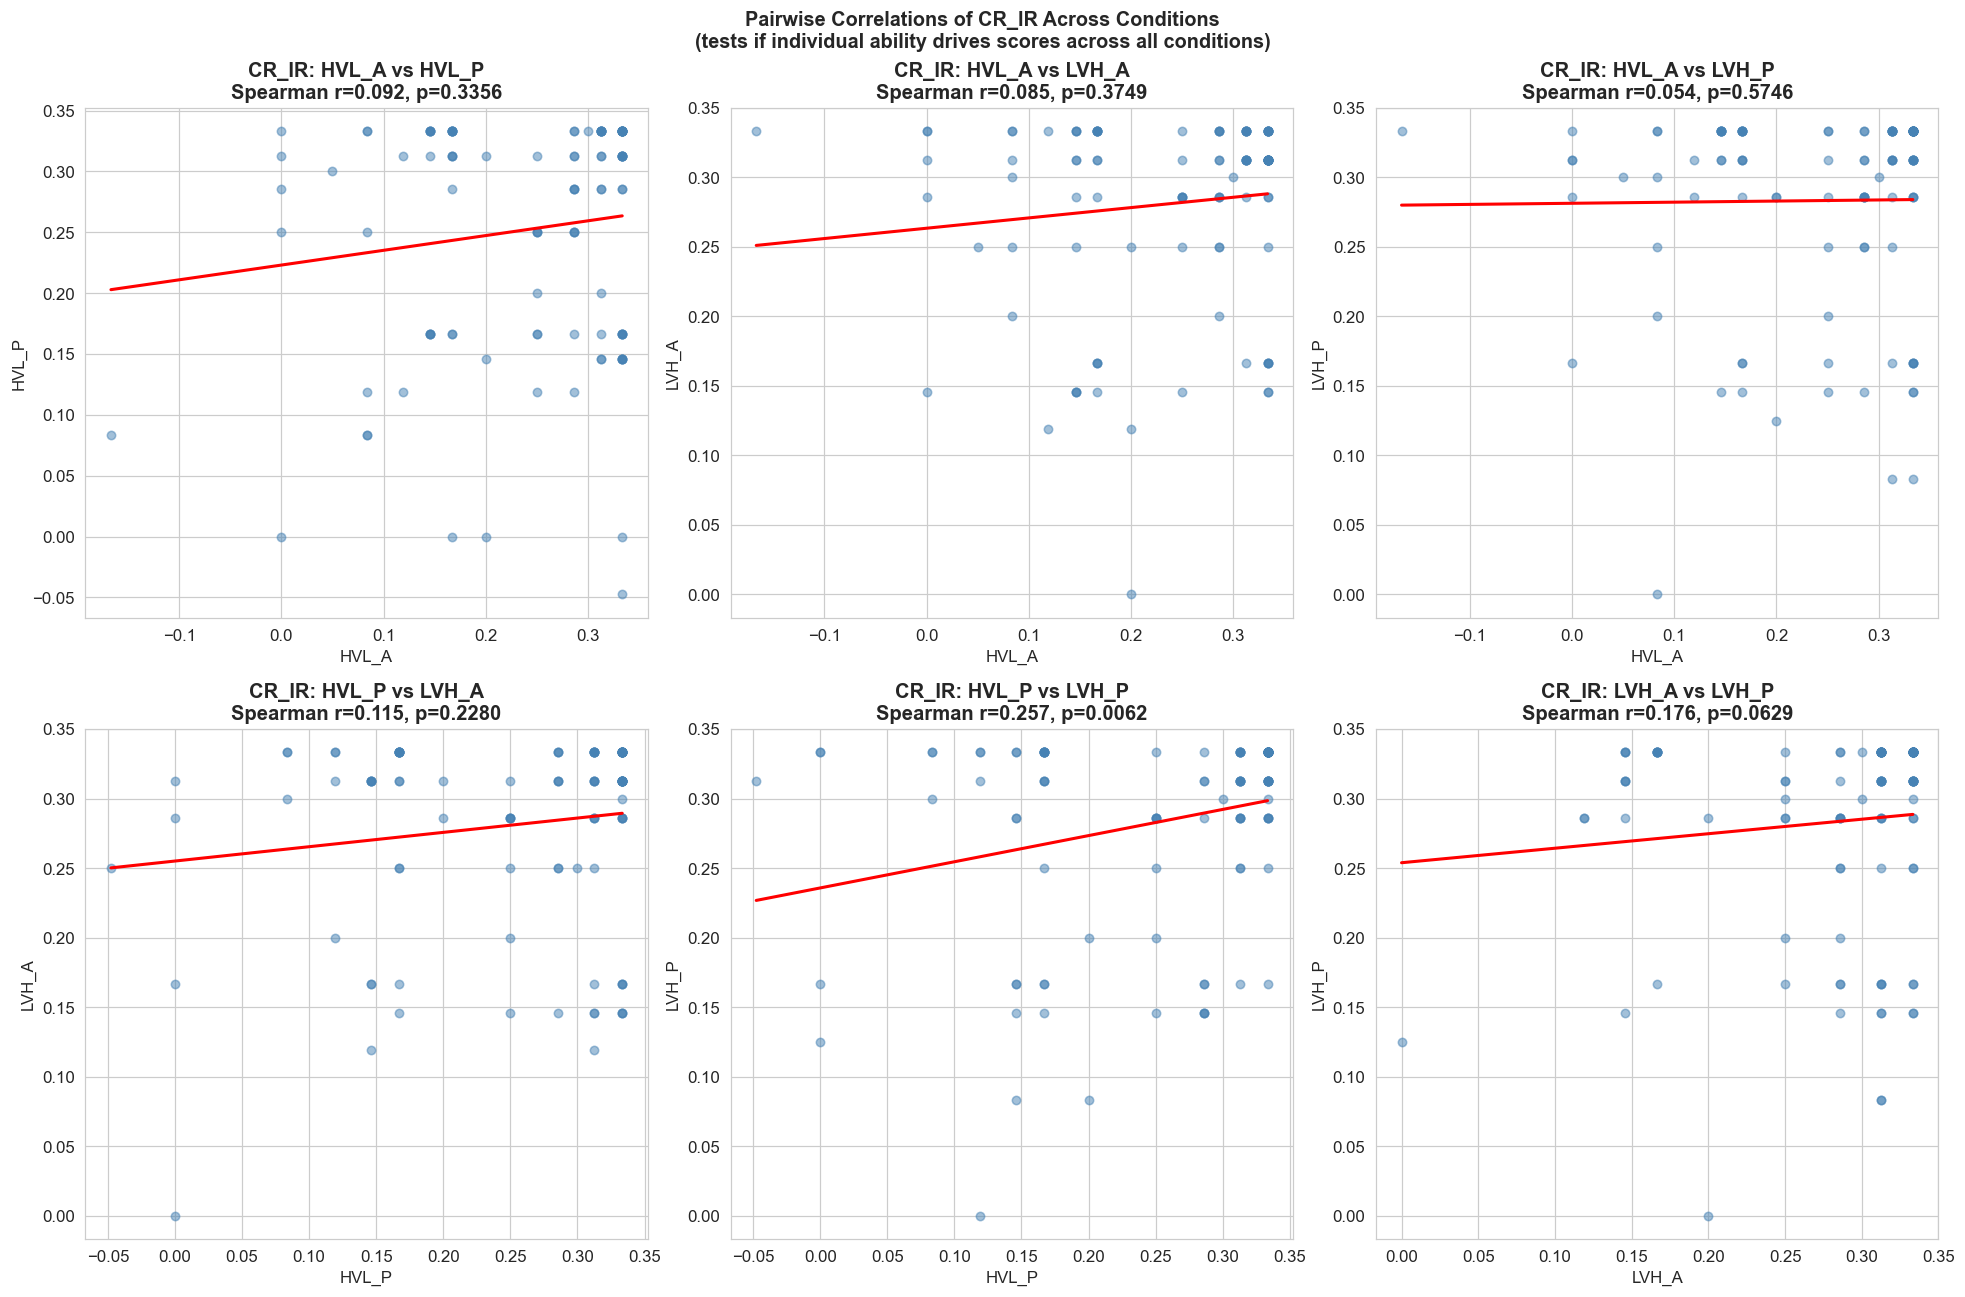

In [86]:
# 12b — CR_IR across conditions (are they correlated?)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

pairs = list(combinations(cond_order[:4], 2))  # pairwise among first 4 conditions

for idx, (c1, c2) in enumerate(pairs[:6]):
    d1 = summary_wide.get(f'cr_ir_{c1}', pd.Series(dtype=float))
    d2 = summary_wide.get(f'cr_ir_{c2}', pd.Series(dtype=float))
    if d1.empty or d2.empty:
        continue
    valid = d1.notna() & d2.notna()
    r, p = spearmanr(d1[valid], d2[valid])
    axes[idx].scatter(d1[valid], d2[valid], alpha=0.5, color='steelblue', s=30)
    axes[idx].set_xlabel(c1)
    axes[idx].set_ylabel(c2)
    axes[idx].set_title(f'CR_IR: {c1} vs {c2}\nSpearman r={r:.3f}, p={p:.4f}', fontweight='bold')
    # Add regression line
    m, b = np.polyfit(d1[valid], d2[valid], 1)
    x_line = np.linspace(d1[valid].min(), d1[valid].max(), 100)
    axes[idx].plot(x_line, m*x_line + b, color='red', linewidth=2)

plt.suptitle('Pairwise Correlations of CR_IR Across Conditions\n(tests if individual ability drives scores across all conditions)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

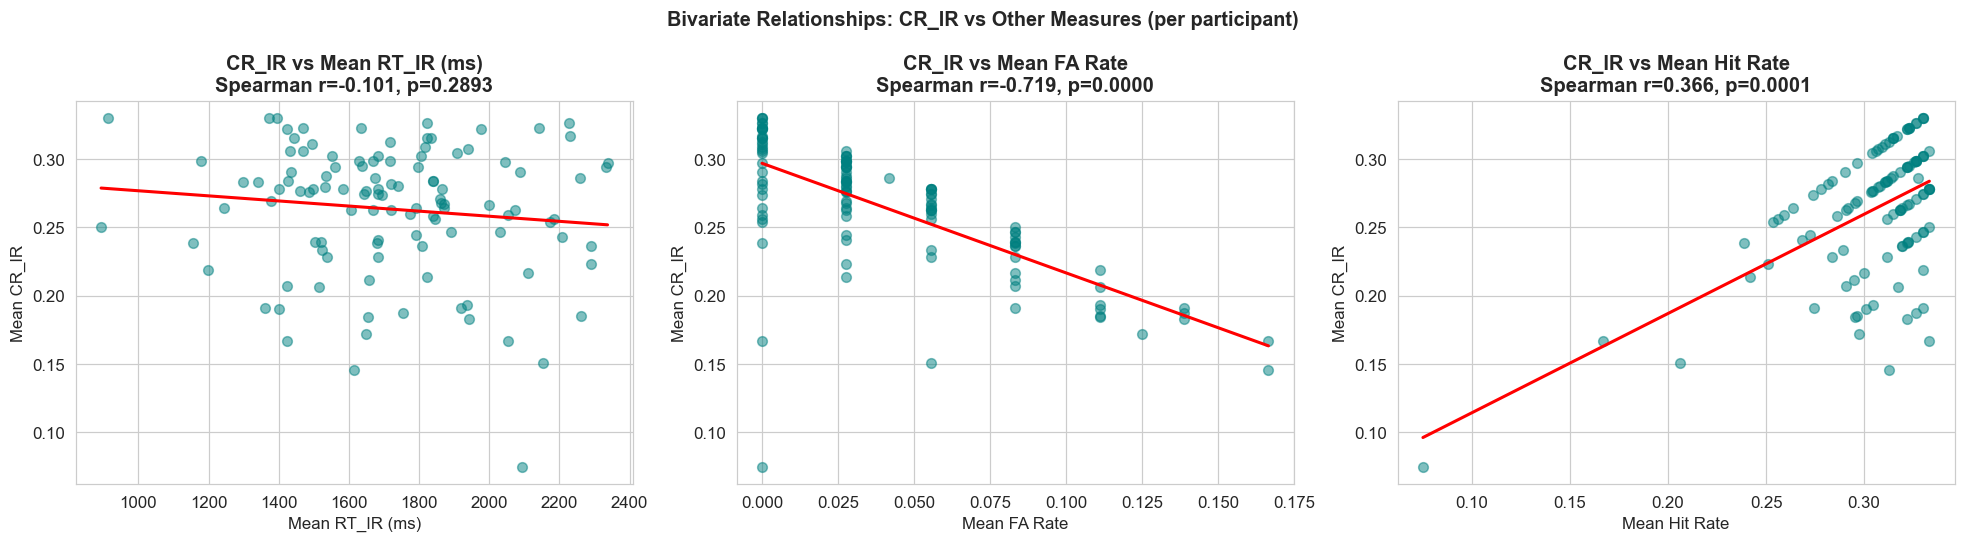

In [87]:
# 12c — CR_IR vs RT_IR, FA rate scatter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CR_IR vs mean RT_IR (per participant, averaged across conditions)
p_cr_rt = cr_long_final.groupby('participant_ID').agg(
    mean_cr  = ('cr_ir', 'mean'),
    mean_rt  = ('mean_rt_ir_clean', 'mean'),
    mean_fa  = ('fa_rate', 'mean'),
    mean_hit = ('hit_rate_ir', 'mean'),
).reset_index().dropna()

for ax_idx, (x_var, x_label) in enumerate([
    ('mean_rt', 'Mean RT_IR (ms)'),
    ('mean_fa', 'Mean FA Rate'),
    ('mean_hit', 'Mean Hit Rate'),
]):
    r, p = spearmanr(p_cr_rt[x_var], p_cr_rt['mean_cr'])
    axes[ax_idx].scatter(p_cr_rt[x_var], p_cr_rt['mean_cr'], alpha=0.5, color='teal', s=40)
    m, b = np.polyfit(p_cr_rt[x_var], p_cr_rt['mean_cr'], 1)
    x_line = np.linspace(p_cr_rt[x_var].min(), p_cr_rt[x_var].max(), 100)
    axes[ax_idx].plot(x_line, m*x_line + b, color='red', linewidth=2)
    axes[ax_idx].set_xlabel(x_label)
    axes[ax_idx].set_ylabel('Mean CR_IR')
    axes[ax_idx].set_title(f'CR_IR vs {x_label}\nSpearman r={r:.3f}, p={p:.4f}', fontweight='bold')

plt.suptitle('Bivariate Relationships: CR_IR vs Other Measures (per participant)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 13 — EDA: WR (Word Recognition) Analysis

WR accuracy tells us whether participants recognized the **exact** sentence (same voice) vs a transformed version (different voice).


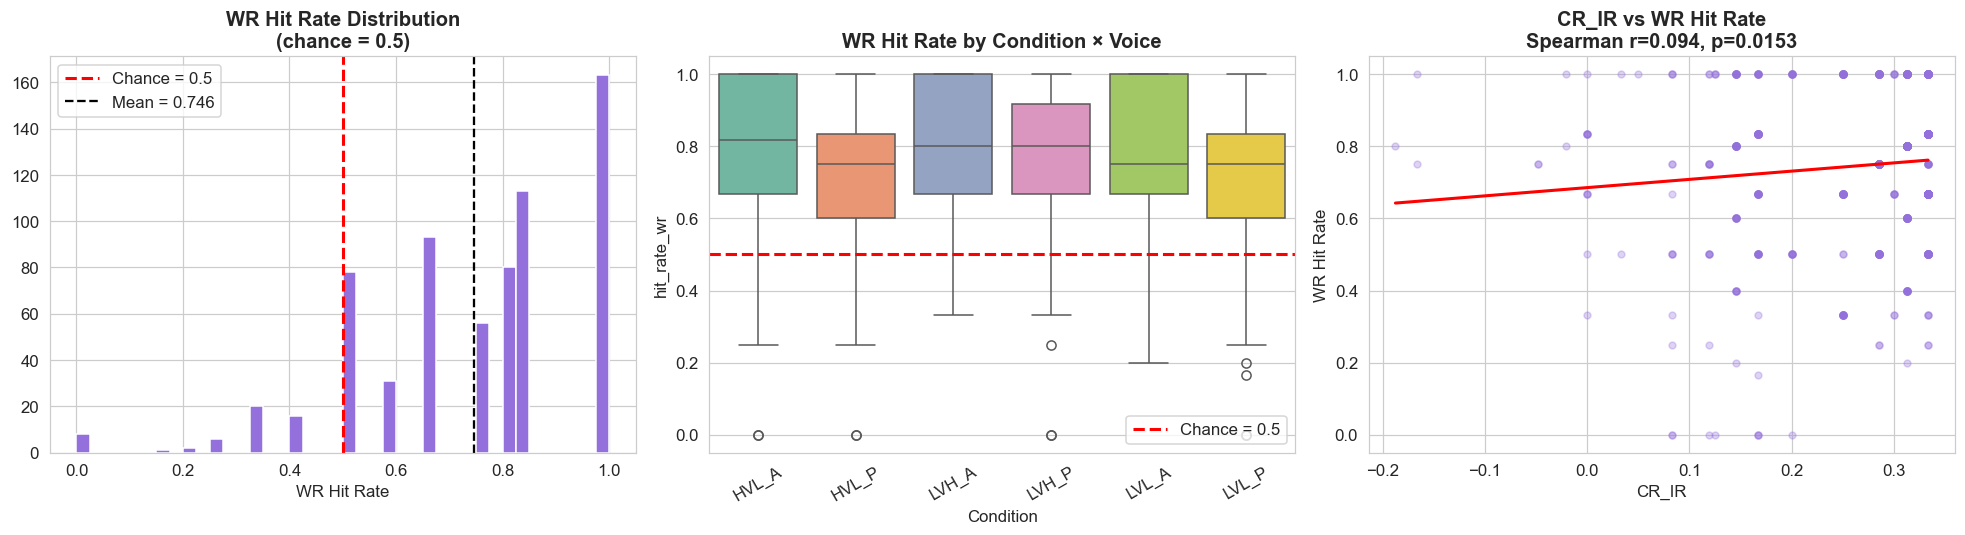

WR hit rate by condition:
             mean  median    std  count
cond_voice                             
HVL_A      0.7751  0.8167 0.2076    112
HVL_P      0.7197  0.7500 0.2107    111
LVH_A      0.7685  0.8000 0.1942    111
LVH_P      0.7547  0.8000 0.2112    111
LVL_A      0.7436  0.7500 0.2084    110
LVL_P      0.7173  0.7500 0.2320    112

--- One-sample t-test: WR hit rate vs 0.5 (chance) ---
HVL_A       : mean=0.775, t=14.03, p=0.0000 **
HVL_P       : mean=0.720, t=10.98, p=0.0000 **
LVH_A       : mean=0.768, t=14.57, p=0.0000 **
LVH_P       : mean=0.755, t=12.70, p=0.0000 **
LVL_A       : mean=0.744, t=12.26, p=0.0000 **
LVL_P       : mean=0.717, t=9.91, p=0.0000 **


In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# WR hit rate distribution
axes[0].hist(cr_long_final['hit_rate_wr'].dropna(), bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Chance = 0.5')
axes[0].axvline(cr_long_final['hit_rate_wr'].mean(), color='black', linestyle='--',
                label=f'Mean = {cr_long_final["hit_rate_wr"].mean():.3f}')
axes[0].set_title('WR Hit Rate Distribution\n(chance = 0.5)', fontweight='bold')
axes[0].set_xlabel('WR Hit Rate')
axes[0].legend()

# WR by condition
sns.boxplot(data=cr_long_final, x='cond_voice', y='hit_rate_wr',
            order=cond_order, ax=axes[1], palette='Set2')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=2, label='Chance = 0.5')
axes[1].set_title('WR Hit Rate by Condition × Voice', fontweight='bold')
axes[1].set_xlabel('Condition')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

# WR vs CR_IR scatter
valid = cr_long_final[['cr_ir','hit_rate_wr']].dropna()
r, p = spearmanr(valid['cr_ir'], valid['hit_rate_wr'])
axes[2].scatter(valid['cr_ir'], valid['hit_rate_wr'], alpha=0.3, color='mediumpurple', s=20)
m, b = np.polyfit(valid['cr_ir'], valid['hit_rate_wr'], 1)
x_line = np.linspace(valid['cr_ir'].min(), valid['cr_ir'].max(), 100)
axes[2].plot(x_line, m*x_line + b, color='red', linewidth=2)
axes[2].set_xlabel('CR_IR')
axes[2].set_ylabel('WR Hit Rate')
axes[2].set_title(f'CR_IR vs WR Hit Rate\nSpearman r={r:.3f}, p={p:.4f}', fontweight='bold')

plt.tight_layout()
plt.show()

print('WR hit rate by condition:')
print(cr_long_final.groupby('cond_voice')['hit_rate_wr'].agg(['mean','median','std','count']).to_string())

# One-sample t-test against chance (0.5)
print('\n--- One-sample t-test: WR hit rate vs 0.5 (chance) ---')
for cv in cond_order:
    data = cr_long_final[cr_long_final['cond_voice'] == cv]['hit_rate_wr'].dropna()
    t, p = stats.ttest_1samp(data, 0.5)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')
    print(f'{cv:<12}: mean={data.mean():.3f}, t={t:.2f}, p={p:.4f} {sig}')

## STEP 14 — EDA: FA Rate Deep Dive



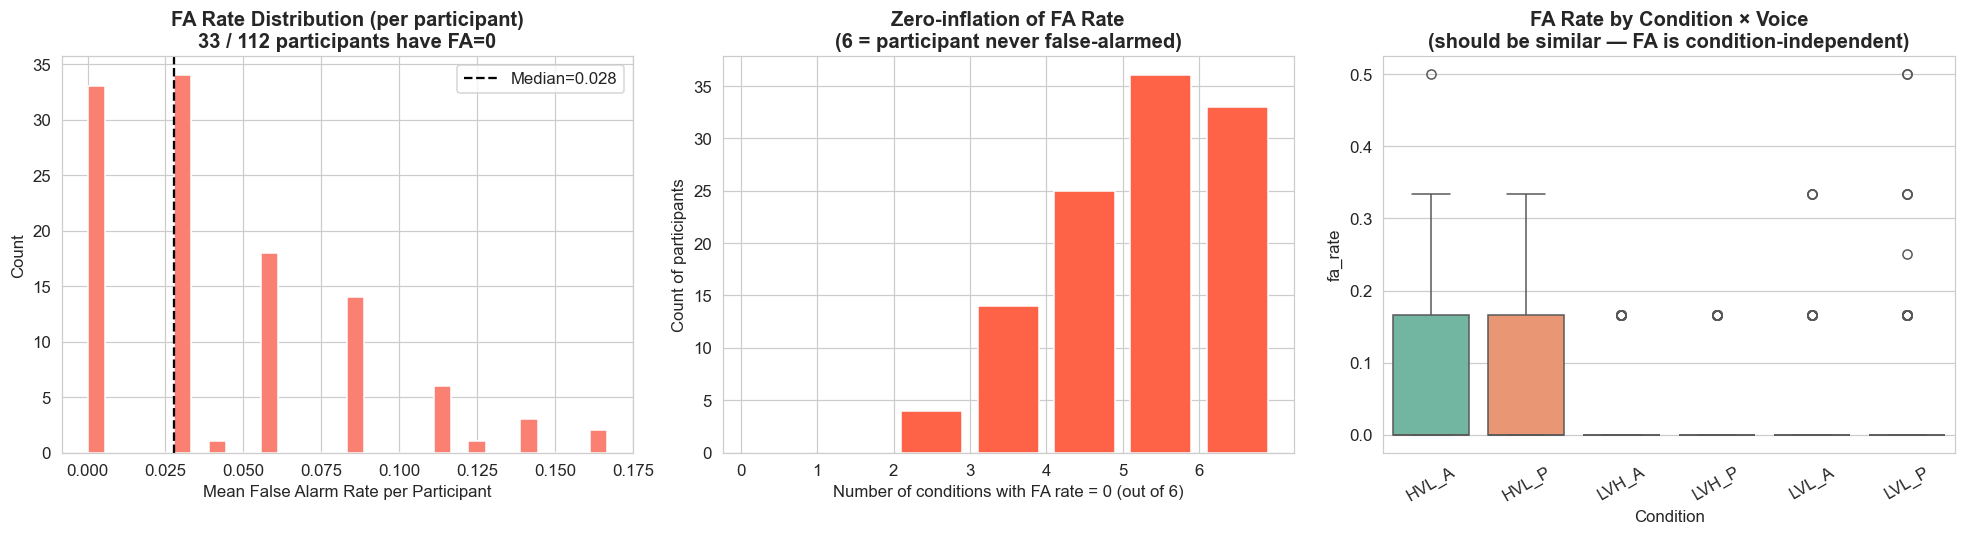

FA rate by condition:
              count   mean    std    min    25%    50%    75%    max
cond_voice                                                          
HVL_A      112.0000 0.0714 0.1078 0.0000 0.0000 0.0000 0.1667 0.5000
HVL_P      112.0000 0.0573 0.0943 0.0000 0.0000 0.0000 0.1667 0.3333
LVH_A      112.0000 0.0268 0.0615 0.0000 0.0000 0.0000 0.0000 0.1667
LVH_P      112.0000 0.0238 0.0586 0.0000 0.0000 0.0000 0.0000 0.1667
LVL_A      112.0000 0.0268 0.0727 0.0000 0.0000 0.0000 0.0000 0.3333
LVL_P      112.0000 0.0454 0.1012 0.0000 0.0000 0.0000 0.0000 0.5000


In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FA rate distribution
fa_per_p = cr_long_final.groupby('participant_ID')['fa_rate'].mean().dropna()
axes[0].hist(fa_per_p, bins=30, color='salmon', edgecolor='white')
axes[0].axvline(fa_per_p.median(), color='black', linestyle='--',
                label=f'Median={fa_per_p.median():.3f}')
axes[0].set_xlabel('Mean False Alarm Rate per Participant')
axes[0].set_ylabel('Count')
axes[0].set_title(f'FA Rate Distribution (per participant)\n'
                   f'{(fa_per_p == 0).sum()} / {len(fa_per_p)} participants have FA=0', fontweight='bold')
axes[0].legend()

# FA = 0 count per participant (how many conditions have FA=0)
fa_zero_counts = (cr_long_final.groupby('participant_ID')['fa_rate'] == 0).sum() if False else \
    cr_long_final.groupby('participant_ID')['fa_rate'].apply(lambda x: (x == 0).sum())
axes[1].hist(fa_zero_counts, bins=range(0, 8), color='tomato', edgecolor='white', rwidth=0.8)
axes[1].set_xlabel('Number of conditions with FA rate = 0 (out of 6)')
axes[1].set_ylabel('Count of participants')
axes[1].set_title('Zero-inflation of FA Rate\n(6 = participant never false-alarmed)', fontweight='bold')
axes[1].set_xticks(range(0, 7))

# FA rate by condition
sns.boxplot(data=cr_long_final, x='cond_voice', y='fa_rate',
            order=cond_order, ax=axes[2], palette='Set2')
axes[2].set_title('FA Rate by Condition × Voice\n(should be similar — FA is condition-independent)', fontweight='bold')
axes[2].set_xlabel('Condition')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('FA rate by condition:')
print(cr_long_final.groupby('cond_voice')['fa_rate'].describe().to_string())

## STEP 15 — EDA: Preliminary Statistical Tests (Kruskal-Wallis)



In [90]:
print('=== KRUSKAL-WALLIS TESTS ===')
print()

# Test 1: Effect of memorability condition (collapsed across voice)
groups_cond = [cr_long_final[cr_long_final['condition'] == c]['cr_ir'].dropna().values
               for c in TARGET_CONDITIONS]
stat, p = kruskal(*groups_cond)
print(f'Memorability (HVL vs LVH vs LVL, all voices): H={stat:.4f}, p={p:.4f} '
      f'{"***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"}')

# Test 2: Within each voice
for voice in ['A', 'P']:
    grps = [cr_long_final[(cr_long_final['condition']==c) & (cr_long_final['voice']==voice)]['cr_ir'].dropna().values
            for c in TARGET_CONDITIONS]
    stat, p = kruskal(*grps)
    label = 'Active' if voice == 'A' else 'Passive'
    print(f'Memorability within {label}: H={stat:.4f}, p={p:.4f} '
          f'{"***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"}')

# Test 3: Effect of voice (collapsed across conditions)
active  = cr_long_final[cr_long_final['voice'] == 'A']['cr_ir'].dropna().values
passive = cr_long_final[cr_long_final['voice'] == 'P']['cr_ir'].dropna().values
stat, p = kruskal(active, passive)
print(f'\nVoice (Active vs Passive, all conditions): H={stat:.4f}, p={p:.4f} '
      f'{"***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"}')

print()
print('=== WILCOXON SIGNED-RANK TESTS (pairwise, paired by participant) ===')
print()

# For paired tests, we need wide format
for c1, c2 in combinations(TARGET_CONDITIONS, 2):
    for voice in ['A', 'P']:
        d1 = cr_long_final[(cr_long_final['condition']==c1) & (cr_long_final['voice']==voice)]\
             .set_index('participant_ID')['cr_ir']
        d2 = cr_long_final[(cr_long_final['condition']==c2) & (cr_long_final['voice']==voice)]\
             .set_index('participant_ID')['cr_ir']
        merged = pd.concat([d1, d2], axis=1, keys=[c1, c2]).dropna()
        if len(merged) < 10: continue
        stat, p = wilcoxon(merged[c1], merged[c2])
        direction = '>' if merged[c1].mean() > merged[c2].mean() else '<'
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'{c1} {direction} {c2} ({"Active" if voice=="A" else "Passive"}): '
              f'W={stat:.1f}, p={p:.4f} {sig} '
              f'(means: {merged[c1].mean():.3f} vs {merged[c2].mean():.3f})')

=== KRUSKAL-WALLIS TESTS ===

Memorability (HVL vs LVH vs LVL, all voices): H=11.3538, p=0.0034 **
Memorability within Active: H=6.9577, p=0.0308 *
Memorability within Passive: H=5.5671, p=0.0618 ns

Voice (Active vs Passive, all conditions): H=0.5518, p=0.4576 ns

=== WILCOXON SIGNED-RANK TESTS (pairwise, paired by participant) ===

HVL < LVH (Active): W=1027.0, p=0.0007 *** (means: 0.239 vs 0.281)
HVL < LVH (Passive): W=1005.5, p=0.0116 * (means: 0.252 vs 0.283)
HVL < LVL (Active): W=1292.5, p=0.0189 * (means: 0.239 vs 0.269)
HVL < LVL (Passive): W=1642.0, p=0.5229 ns (means: 0.252 vs 0.255)
LVH > LVL (Active): W=1340.0, p=0.3172 ns (means: 0.281 vs 0.269)
LVH > LVL (Passive): W=1175.5, p=0.0222 * (means: 0.283 vs 0.255)


## STEP 16 — EDA: Voice Effect Analysis

We compare Active vs Passive voice within each memorability condition.



HVL: Active mean=0.2388 | Passive mean=0.2520
LVH: Active mean=0.2810 | Passive mean=0.2831
LVL: Active mean=0.2695 | Passive mean=0.2549


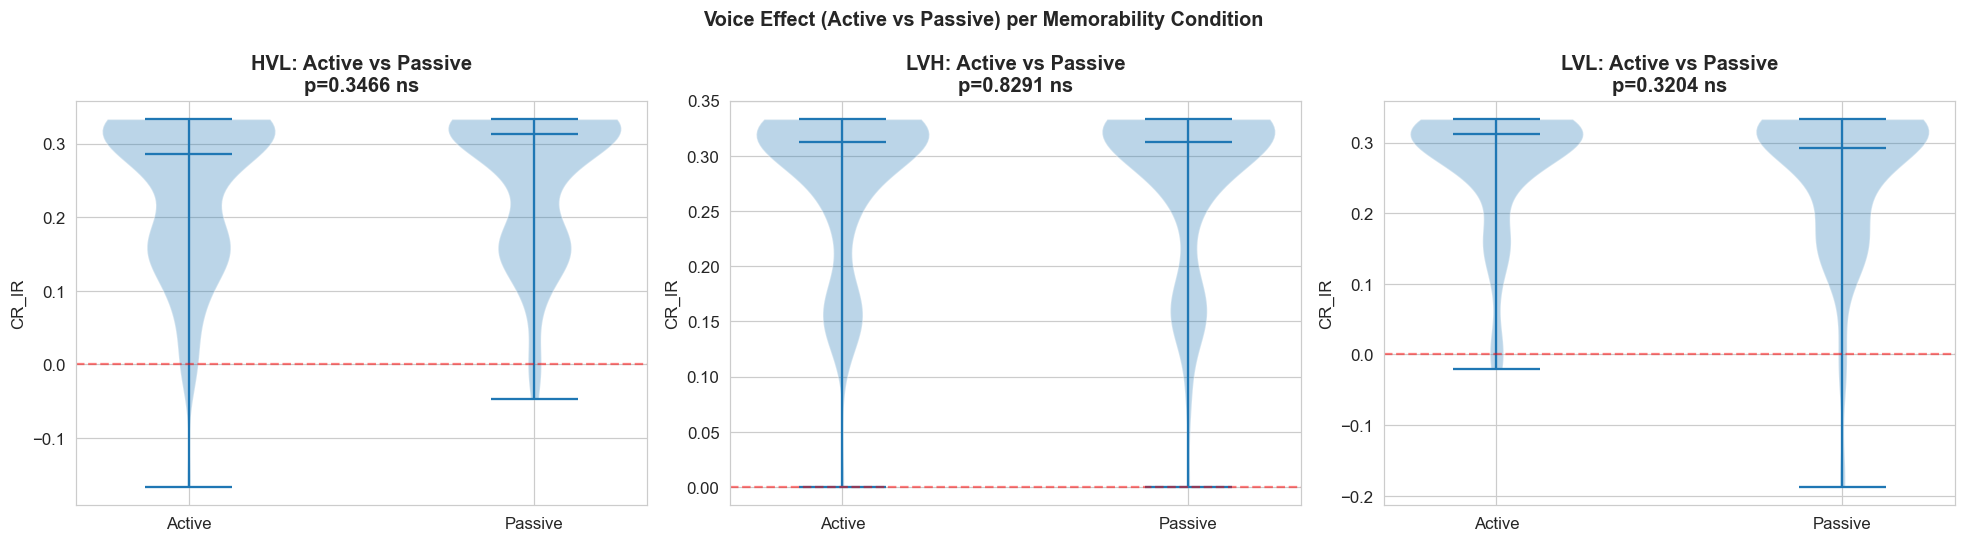

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, cond in enumerate(TARGET_CONDITIONS):
    sub = cr_long_final[cr_long_final['condition'] == cond]
    a_data = sub[sub['voice'] == 'A']['cr_ir'].dropna()
    p_data = sub[sub['voice'] == 'P']['cr_ir'].dropna()

    # Paired Wilcoxon
    merged = pd.concat([
        sub[sub['voice']=='A'].set_index('participant_ID')['cr_ir'],
        sub[sub['voice']=='P'].set_index('participant_ID')['cr_ir']
    ], axis=1, keys=['Active','Passive']).dropna()

    if len(merged) >= 10:
        stat, p = wilcoxon(merged['Active'], merged['Passive'])
        title_p = f'p={p:.4f} {"*" if p < 0.05 else "ns"}'
    else:
        title_p = 'insufficient data'

    axes[idx].violinplot([a_data, p_data], positions=[0, 1], showmedians=True)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Active', 'Passive'])
    axes[idx].set_title(f'{cond}: Active vs Passive\n{title_p}', fontweight='bold')
    axes[idx].set_ylabel('CR_IR')
    axes[idx].axhline(0, color='red', linestyle='--', alpha=0.5)
    print(f'{cond}: Active mean={a_data.mean():.4f} | Passive mean={p_data.mean():.4f}')

plt.suptitle('Voice Effect (Active vs Passive) per Memorability Condition', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()